<h1 style="text-align: center;">HEART DISEASE PREDICTION</h1>

## 1) Dataset Introduction:

Heart disease is also known as Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year which is about 32% of all deaths globally. CVDs are a group of disorders of the heart and blood vessels and include coronary heart disease, cerebrovascular disease, rheumatic heart disease, and other conditions. Four out of 5CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age.

The dataset was created by combining five different sources: Cleveland (303 instances), Hungarian (294 instances), Switzerland (123 instances), Long Beach VA (200 instances), and the Statlog (Heart) Data Set (270 instances). In total, the dataset contains 1190 instances.

The dataset contains the following 12 columns (11 features and 1 target variable):
| Column        | Description                                                                 | Values / Categories                                                                 |
|--------------------|-----------------------------------------------------------------------------|-------------------------------------------------------------------------------------|
| age                | Patient's age in years                                                     | Numeric                                                                             |
| sex                | Patient's gender                                                           | 0: Female<br>1: Male                                                                |
| chest pain type    | Chest pain type                                                            | 1: Typical angina<br>2: Atypical angina<br>3: Non-anginal pain<br>4: Asymptomatic   |
| resting bp s       | Level of blood pressure at rest (mm/HG)                                    | Numeric                                                                             |
| cholesterol        | Serum cholesterol in mg/dl                                                 | Numeric                                                                             |
| fasting blood sugar| Fasting blood sugar > 120 mg/dl                                             | 0: False<br>1: True                                                                 |
| resting ecg        | Electrocardiogram results at rest                                          | 0: Normal<br>1: ST-T wave abnormality<br>2: Left ventricular hypertrophy            |
| max heart rate     | Maximum heart rate achieved                                                | Numeric                                                                             |
| exercise angina    | Angina induced by exercise                                                 | 0: No<br>1: Yes                                                                     |
| oldpeak            | ST-depression induced by exercise relative to rest                         | Numeric                                                                             |
| ST slope           | ST segment slope during peak exercise                                      | 1: Upsloping<br>2: Flat<br>3: Downsloping                              |
| target             | Heart risk                                                                 | 0: Normal (no disease)<br>1: Heart disease                                          |

In summary, the dataset contains 11 input features: 5 numerical and 6 categorical.
- Numerical features: age, resting bp s, cholesterol, max heart rate, oldpeak.
- Categorical features: sex, chest pain type, fasting blood sugar, resting ecg, exercise angina, ST slope.

## 2) Importing Libraries:

In [1]:
import warnings
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import re
from typing import List, Tuple
import math
from itertools import combinations
from pathlib import Path

# Imblearn 
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Scikit-learn
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV, cross_val_score
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score, roc_auc_score, make_scorer, roc_curve, auc, precision_recall_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn import metrics
from sklearn.utils import resample

# Models
from catboost import CatBoostClassifier

# Optuna
import optuna

# SHAP
import shap

# Save model
import joblib

# scipy
from scipy.stats import wilcoxon, chi2_contingency

from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

In [2]:
warnings.filterwarnings('ignore')

In [3]:
# Check libraries and Python version.
print("Python version:", sys.version)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Scikit-learn version: 1.6.1


In [4]:
# Configuration
SEED = 2025
SPECIFICITY_SCORER = make_scorer(recall_score, pos_label=0)
SCORING = {
    "accuracy": "accuracy",
    "recall": "recall",
    "specificity": SPECIFICITY_SCORER,
    "precision": "precision",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

N_SPLITS = 10
CV = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
N_BOOTSTRAPS = 1000
CLASSIFICATION_THRESHOLD = 0.5

## 3) Loading the Dataset:

In [5]:
## Kaggle
# def get_csv_file_path(root="/kaggle/input"):
#     csv_files = []
#     for dirname, _, filenames in os.walk(root):
#         for filename in filenames:
#             if filename.lower().endswith(".csv"):
#                 csv_files.append(os.path.join(dirname, filename))

#     if not csv_files:
#         raise FileNotFoundError(f"No CSV file found under '{root}'.")

#     if len(csv_files) > 1:
#         raise ValueError("Multiple CSV files were found. "
#                         "Please specify the intended file:\n" + "\n".join(csv_files))

#     return csv_files[0]

# # Get the file path
# file_path = get_csv_file_path()
# df = pd.read_csv(file_path)

## Local
DATA_PATH = Path("data") / "heart_statlog_cleveland_hungary_final.csv"
df = pd.read_csv(DATA_PATH)

In [6]:
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


## 4) Exploratory Data Analysis (EDA):

### 4.1) Overview of Dataset:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [8]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [9]:
TARGET_LABELS = {0: "No Disease", 1: "Disease"}


def plot_target_distribution(y, title, figsize=(6, 6)):
    target_series = pd.Series(y).map(TARGET_LABELS)
    # Giữ thứ tự lớp ổn định
    counts = target_series.value_counts().reindex(["No Disease", "Disease"], fill_value=0)
    print(counts)

    plt.figure(figsize=figsize)
    plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90, counterclock=False)
    plt.title(title)
    plt.axis("equal")

    plt.show()
    plt.close()

target
No Disease    561
Disease       629
Name: count, dtype: int64


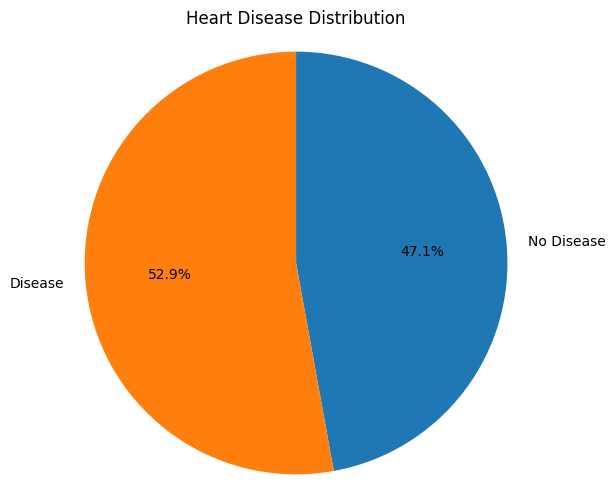

In [10]:
plot_target_distribution(y=df["target"], title="Heart Disease Distribution")

The distribution of the output class is almost balanced, with 52.9% of patients having the disease and 47.1% not having the disease.

### 4.2) Visualizing the categorical variables:

In [11]:
categorical_cols = ["sex", "chest pain type", "fasting blood sugar", "resting ecg", "exercise angina", "ST slope", "target"]

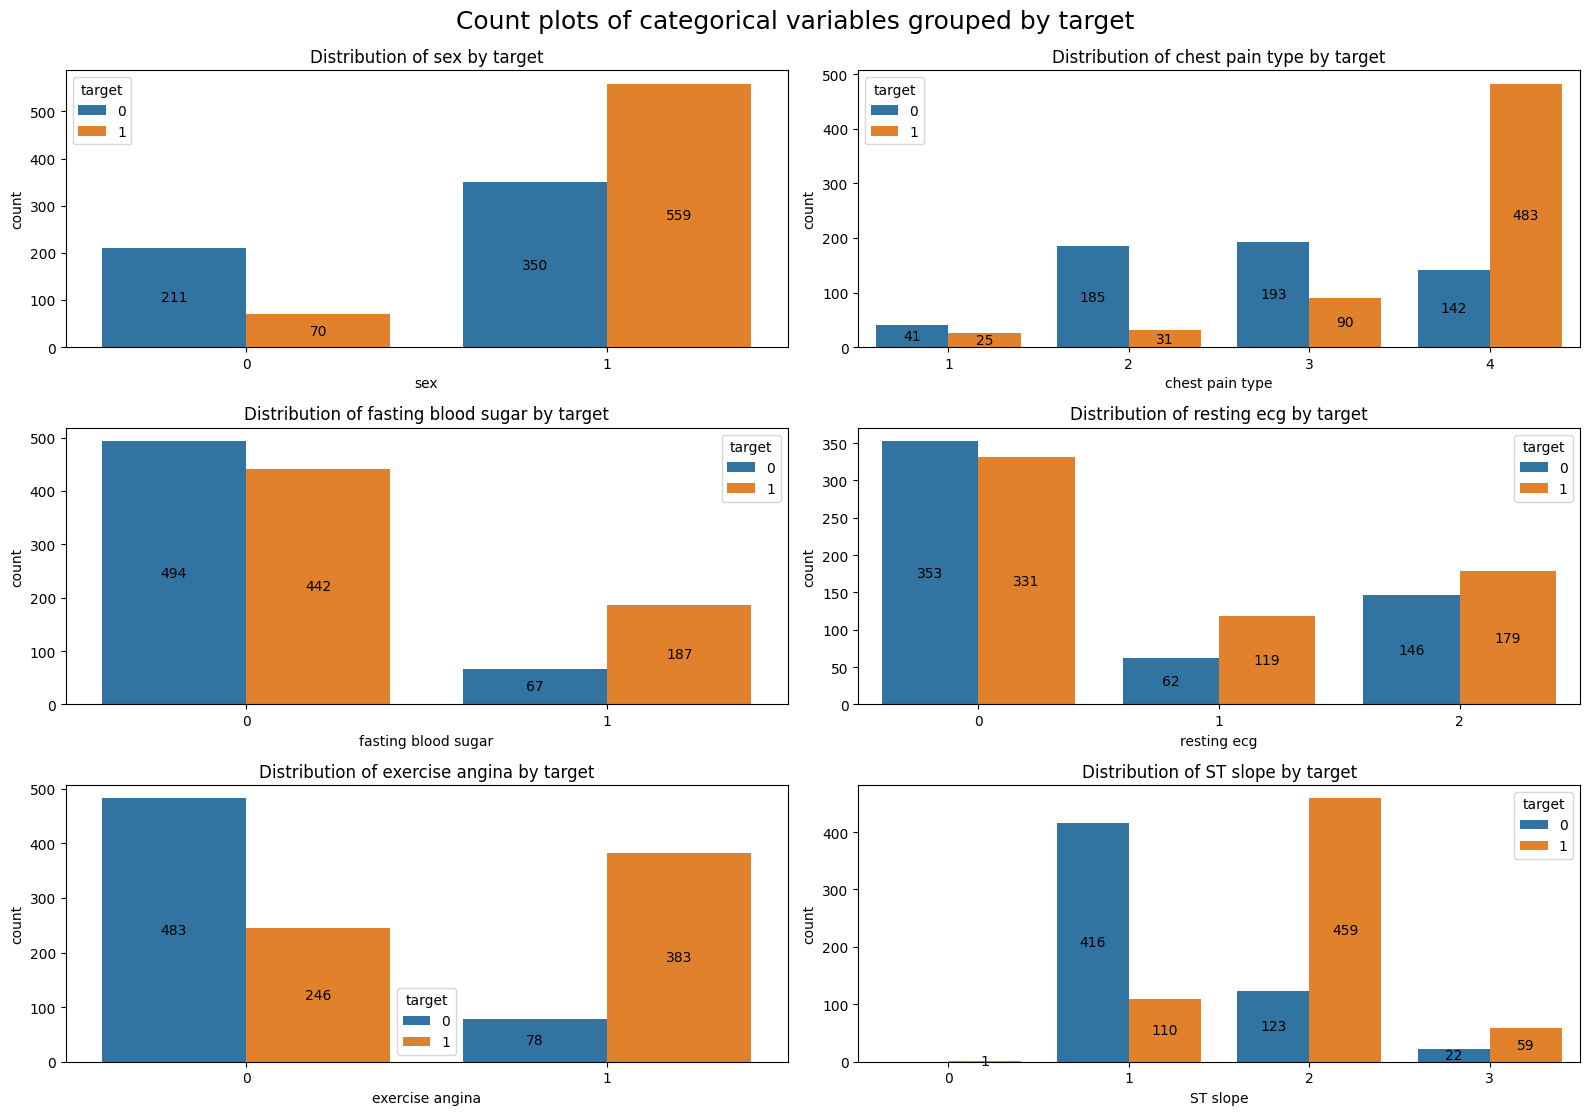

In [12]:
fig = plt.figure(figsize=(16,15))

for idx, col in enumerate(categorical_cols[:-1]):
    ax = plt.subplot(4, 2, idx+1)
    ax.set_title(f"Distribution of {col} by target", fontsize=12)
    # group by HeartDisease
    sns.countplot(x=df[col], hue=df["target"], ax=ax)
    for container in ax.containers:
        ax.bar_label(container, label_type="center")
        
plt.suptitle("Count plots of categorical variables grouped by target", fontsize=18, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()
plt.close()

### 4.3) Visualizing the numerical variables:

In [13]:
numeric_cols = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

In [14]:
print('Skewness values of numerical features:')
skewness = df[numeric_cols].skew().sort_values(ascending=False).rename("Skewness").to_frame()

display(skewness)

Skewness values of numerical features:


,Skewness
oldpeak,1.094006
resting bp s,0.293462
age,-0.192111
max heart rate,-0.233098
cholesterol,-0.781646


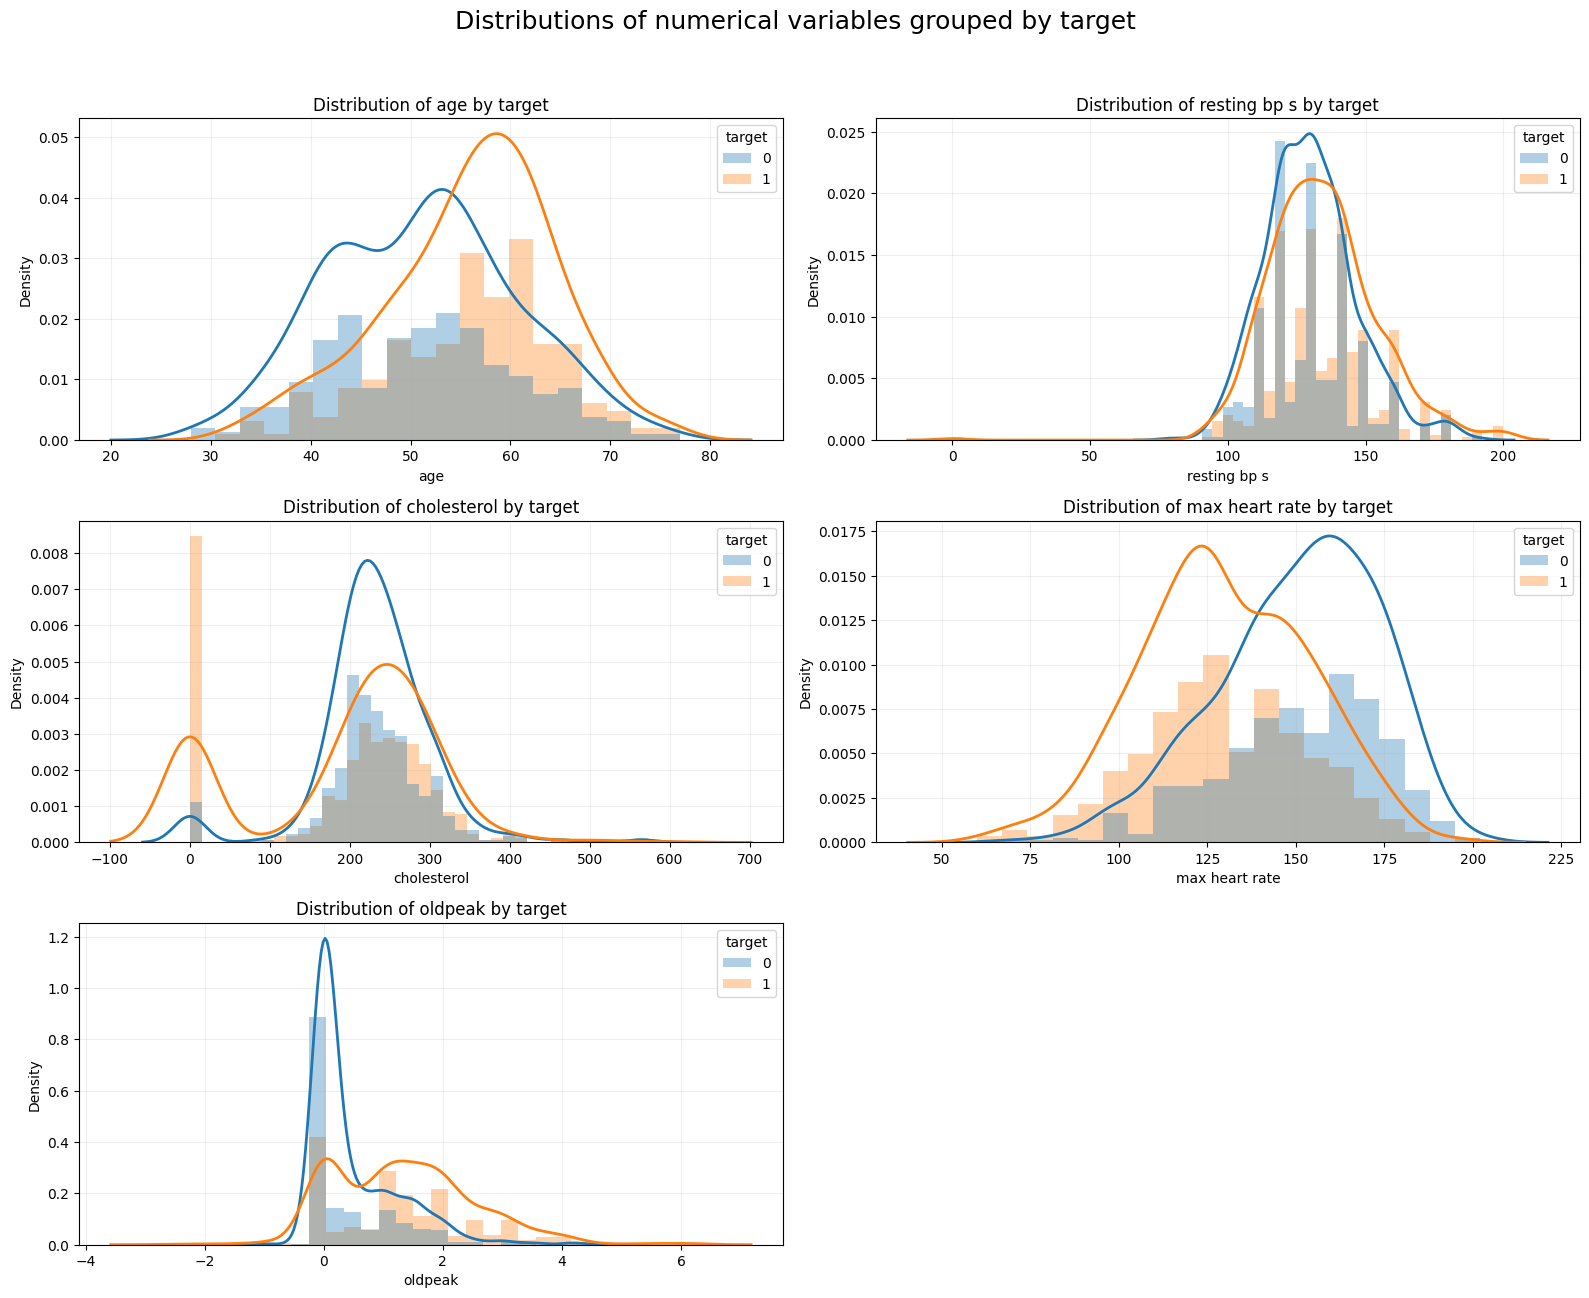

In [15]:
n = len(numeric_cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 1 + 4.0*nrows))
axes = axes.flatten() if n > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    sns.histplot(
        data=df,
        x=col,
        hue='target',
        stat='density',
        bins='auto',
        multiple='layer', 
        alpha=0.35,
        ax=ax,
        edgecolor=None
    )

    for tgt in df['target'].unique():
        sns.kdeplot(
            data=df[df['target'] == tgt],
            x=col,
            ax=ax,
            linewidth=2,
            label=None
        )

    ax.set_title(f"Distribution of {col} by target")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.2)

for j in range(n, nrows*ncols):
    axes[j].set_visible(False)

plt.suptitle("Distributions of numerical variables grouped by target", fontsize=18, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
plt.close()

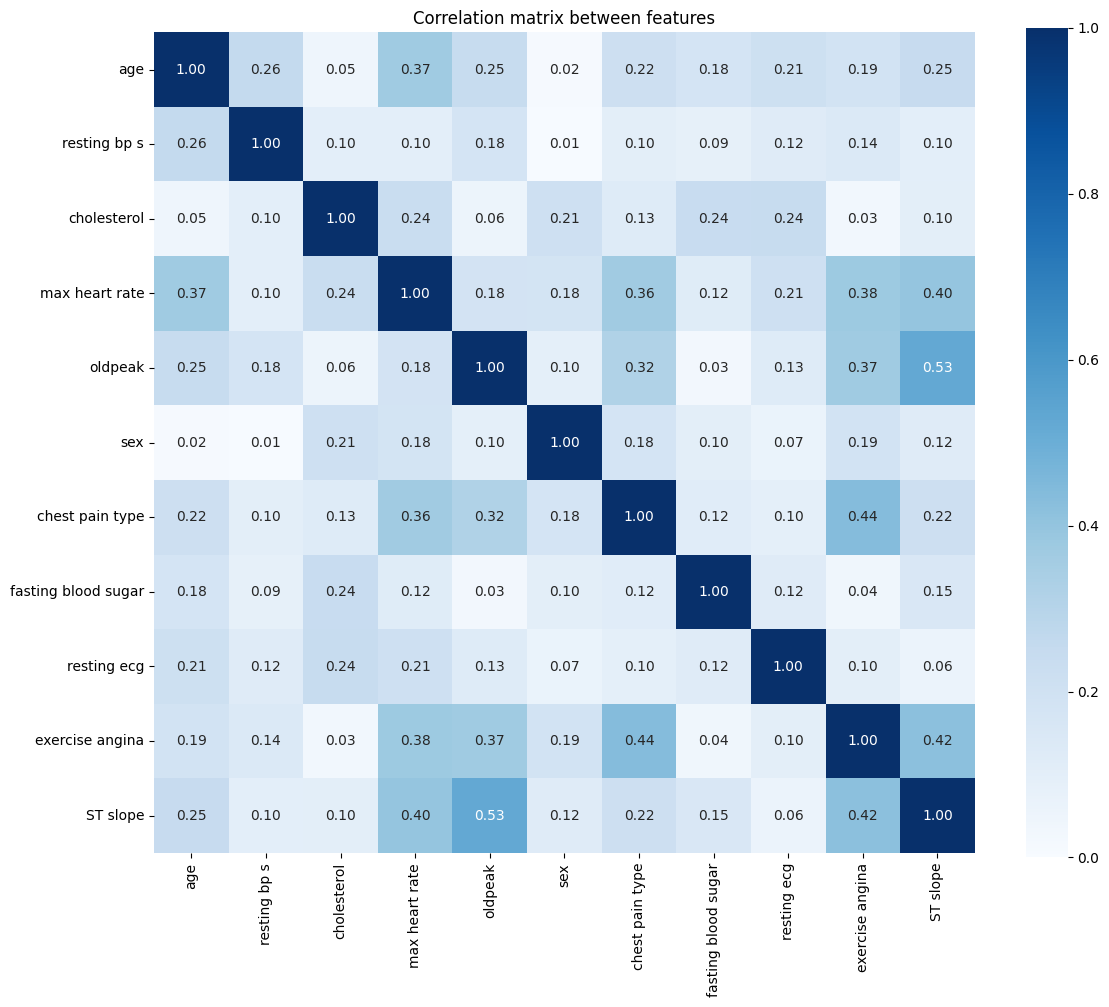

In [16]:
# Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Correlation Ratio
def correlation_ratio(categories, measurements):
    categories = pd.Series(categories)
    measurements = pd.Series(measurements)
    
    y_mean = measurements.mean()
    group_stats = measurements.groupby(categories).agg(['mean', 'count'])
    numerator = sum(group_stats['count'] * (group_stats['mean'] - y_mean)**2)
    denominator = sum((measurements - y_mean)**2)
    
    if denominator == 0:
        return 0.0
    return np.sqrt(numerator / denominator)

# Hàm tạo ma trận
def mixed_correlation_matrix(df, cat_cols, num_cols):
    cols = num_cols + cat_cols
    corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
    
    for i in cols:
        for j in cols:
            if i == j:
                corr_matrix.loc[i, j] = 1.0
            elif i in num_cols and j in num_cols:
                # Trị tuyệt đối của Pearson để đồng nhất thang đo [0,1] với Eta và Cramér's V
                corr_matrix.loc[i, j] = np.abs(df[i].corr(df[j], method='pearson'))
            elif i in cat_cols and j in cat_cols:
                corr_matrix.loc[i, j] = cramers_v(df[i], df[j])
            else:
                num_var = df[i] if i in num_cols else df[j]
                cat_var = df[i] if i in cat_cols else df[j]
                corr_matrix.loc[i, j] = correlation_ratio(cat_var, num_var)
                
    return corr_matrix

num_cols = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
cat_cols = ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']

mixed_corr = mixed_correlation_matrix(df, cat_cols, num_cols)

# Trực quan hóa 
plt.figure(figsize=(12, 10))
sns.heatmap(mixed_corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True)
plt.title("Correlation matrix between features")
plt.tight_layout()
plt.show()
plt.close()

## 5) Data Cleaning:

In [17]:
print(f'Number of rows and columns before preprocessing:')
print(f'- Number of rows: {df.shape[0]}')
print(f'- Number of columns: {df.shape[1]}')

Number of rows and columns before preprocessing:
- Number of rows: 1190
- Number of columns: 12


### 5.1) Duplicated data:

In [18]:
print(df.duplicated().sum())

272


A total of 272 duplicate instances were identified. Since duplicate records may bias the split between the training, validation, and test sets, these duplicates were removed.

In [19]:
print('Duplicated data: ',df.shape)
df.drop_duplicates(inplace=True)
print('Dataset after drop duplicates: ',df.shape)

Duplicated data:  (1190, 12)
Dataset after drop duplicates:  (918, 12)


### 5.2) Missing values:

In [20]:
# Check for missing values in columns.
percentage_missing_dic = {}
for col in df.columns:
    percentage_missing = df[col].isna().mean() * 100
    percentage_missing_dic[col] = percentage_missing
    print(f'The percentage of missing values in the \'{col}\' column is {percentage_missing:.2f}%')

The percentage of missing values in the 'age' column is 0.00%
The percentage of missing values in the 'sex' column is 0.00%
The percentage of missing values in the 'chest pain type' column is 0.00%
The percentage of missing values in the 'resting bp s' column is 0.00%
The percentage of missing values in the 'cholesterol' column is 0.00%
The percentage of missing values in the 'fasting blood sugar' column is 0.00%
The percentage of missing values in the 'resting ecg' column is 0.00%
The percentage of missing values in the 'max heart rate' column is 0.00%
The percentage of missing values in the 'exercise angina' column is 0.00%
The percentage of missing values in the 'oldpeak' column is 0.00%
The percentage of missing values in the 'ST slope' column is 0.00%
The percentage of missing values in the 'target' column is 0.00%


### 5.3) Invalid data:

In [21]:
df.describe() # Details of columns are presented in the table below.

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,3.251634,132.396514,198.799564,0.233115,0.603486,136.809368,0.404139,0.887364,1.636166,0.553377
std,9.432617,0.407701,0.931031,18.514154,109.384145,0.423046,0.805968,25.460334,0.490992,1.066570,0.609341,0.497414
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,173.250000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,138.000000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


- The `age` column includes values between 28 and 77, a valid range for human ages.
- The values in the`sex`, `chest pain type`, `fasting blood sugar`, `resting ecg`, `exercise angina` columns are appropriate.
- The `cholesterol` column contains values of 0, which are *invalid* since human cholesterol levels must always be positive.
- The `ST slope` column contains values of 0, which are *invalid* because according to the dataset documentation, the valid range for this feature is from 1 to 3.
- The `resting bp s` column contains values of 0, which are *invalid* since human blood pressure cannot be zero.
- All values in the `max heart rate`, `oldpeak`, and `target` columns are valid data.

In [22]:
# Process
ZERO_AS_MISSING_COLUMNS = ["ST slope", "resting bp s", "cholesterol"]

def replace_zero_with_nan(dataframe, columns, verbose=True):
    dataframe = dataframe.copy()
    for column in columns:
        if column not in dataframe.columns:
            if verbose:
                print(f"Warning: column '{column}' does not exist in the DataFrame.")
            continue

        zero_count = dataframe[column].eq(0).sum()

        if verbose:
            print(f"{column}: replacing "
                f"{zero_count} zero values with NaN")

        dataframe.loc[dataframe[column].eq(0), column] = np.nan

    return dataframe

In [23]:
df = replace_zero_with_nan(dataframe=df, columns=ZERO_AS_MISSING_COLUMNS)
df[ZERO_AS_MISSING_COLUMNS].isna().sum()

ST slope: replacing 1 zero values with NaN
resting bp s: replacing 1 zero values with NaN
cholesterol: replacing 172 zero values with NaN


ST slope          1
resting bp s      1
cholesterol     172
dtype: int64

## 6) Data Splitting:

In [24]:
train_val_data = df.sample(frac=0.95, random_state=786)
test_data = df.drop(train_val_data.index)

train_val_data.reset_index(inplace=True, drop=True)
test_data.reset_index(inplace=True, drop=True)

print('Data for Modeling: ' + str(train_val_data.shape))
print('Unseen Data For Predictions ' + str(test_data.shape))

Data for Modeling: (872, 12)
Unseen Data For Predictions (46, 12)


target
No Disease    21
Disease       25
Name: count, dtype: int64


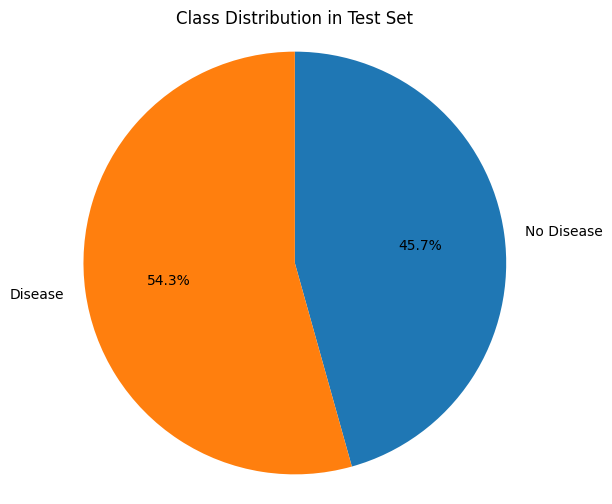

In [25]:
plot_target_distribution(y=test_data["target"], title="Class Distribution in Test Set",)

## 7) ML Configuration:

In [26]:
models = {
        'Logistic Regression': 'lr',
        'K-Nearest Neighbor': 'knn',
        'Support Vector Machine': 'svm',
        'Decision Tree': 'dt',
        'Random Forest': 'rf',
        'Extra Trees': 'et',
        'CatBoost': 'cb'
        }

df_clean = train_val_data.copy()
X = df_clean.drop(columns=['target'])
y = df_clean['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.3, random_state=SEED)

target
No Disease    272
Disease       338
Name: count, dtype: int64


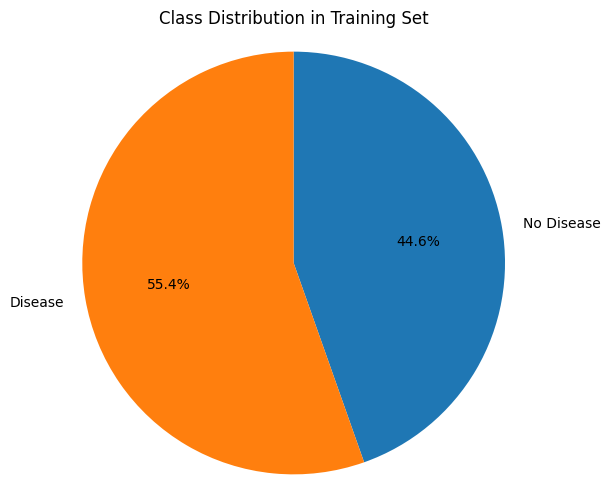

In [27]:
plot_target_distribution(y=y_train, title="Class Distribution in Training Set")

target
No Disease    117
Disease       145
Name: count, dtype: int64


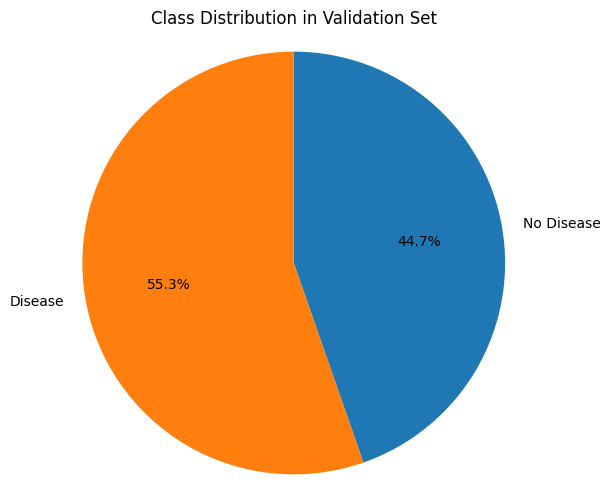

In [28]:
plot_target_distribution(y=y_val, title="Class Distribution in Validation Set")

In [29]:
# Helper
def make_estimator(model_code: str, random_state: int):
    estimators = {
        "rf": lambda: RandomForestClassifier(random_state=random_state, n_jobs=-1),
        "lr": lambda: LogisticRegression(max_iter=1000, n_jobs=-1),
        "dt": lambda: DecisionTreeClassifier(random_state=random_state),
        "svm": lambda: SVC(random_state=random_state, probability=True),
        "knn": KNeighborsClassifier,
        "et": lambda: ExtraTreesClassifier(n_jobs=-1, random_state=random_state),
        "cb": lambda: CatBoostClassifier(verbose=0, random_seed=random_state),
    }

    try:
        return estimators[model_code]()
    except KeyError:
        raise ValueError(f"Unsupported model code: {model_code}")

# Identify the type of variable
def split_feature_types(df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    cols = [c for c in df.columns if c != "target"]
    candidate_cat = ['sex', 'chest_pain_type', 'fasting_blood_sugar',
                     'resting_ecg', 'exercise_angina', 'st_slope']
    cat_cols = [c for c in candidate_cat if c in cols]
    numeric_cols = [c for c in cols if c not in cat_cols]
    return numeric_cols, cat_cols

In [30]:
# Normalize column names
class CleanColumnNames(BaseEstimator, TransformerMixin):
    @staticmethod
    def _clean_name(name):
        name = str(name).strip().lower()
        name = re.sub(r"[^\w]+", "_", name)
        name = re.sub(r"_+", "_", name)
        return name.strip("_")

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            return X
        X = X.copy()
        X.columns = [self._clean_name(column) for column in X.columns]
        return X
        
# OHE (applied only to cat columns)
class PandasOHE(BaseEstimator, TransformerMixin):
    """One-Hot Encode categorical columns, passthrough numerical columns."""
    def __init__(self, drop=None, cat_cols=None):
        self.cat_cols = cat_cols
        self.drop = drop
        self.encoder_ = None
        self.num_cols_ = None
        self.cat_cols_ = None

    def fit(self, X, y=None):
        X = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.cat_cols_ = [c for c in (self.cat_cols or []) if c in X.columns]
        self.num_cols_ = [c for c in X.columns if c not in self.cat_cols_]
        if self.cat_cols_:
            self.encoder_ = OneHotEncoder(drop=self.drop, handle_unknown="ignore", sparse_output=False)
            self.encoder_.fit(X[self.cat_cols_])
        return self

    def transform(self, X):
        X = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        parts = []
        if self.num_cols_:
            parts.append(X[self.num_cols_])
        if self.cat_cols_ and self.encoder_ is not None:
            ohe_data = self.encoder_.transform(X[self.cat_cols_])
            ohe_cols = self.encoder_.get_feature_names_out(
                self.cat_cols_
            )
            parts.append(pd.DataFrame(ohe_data,columns=ohe_cols,index=X.index))
    
        if parts:
            return pd.concat(parts, axis=1)
    
        return X


# Imputer (separate strategies)
class PandasImputer(BaseEstimator, TransformerMixin):
    """Impute numerical columns with median, categorical with most_frequent."""
    def __init__(self, num_cols=None, cat_cols=None):
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self.num_imputer_ = None
        self.cat_imputer_ = None

    def fit(self, X, y=None):
        X = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.num_cols_ = [c for c in (self.num_cols or []) if c in X.columns]
        self.cat_cols_ = [c for c in (self.cat_cols or []) if c in X.columns]
        
        if self.num_cols_:
            self.num_imputer_ = SimpleImputer(strategy="median").fit(X[self.num_cols_])
    
        if self.cat_cols_:
            self.cat_imputer_ = SimpleImputer(strategy="most_frequent").fit(X[self.cat_cols_])
        return self

    def transform(self, X):
        X = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X).copy()
    
        if self.num_cols_ and self.num_imputer_ is not None:
            X[self.num_cols_] = self.num_imputer_.transform(X[self.num_cols_])
    
        if self.cat_cols_ and self.cat_imputer_ is not None:
            X[self.cat_cols_] = self.cat_imputer_.transform(X[self.cat_cols_])
        return X


# Yeo-Johnson PowerTransformer (numeric only)
class ConditionalPowerTransformer(BaseEstimator, TransformerMixin):
    """
    Apply Yeo-Johnson PowerTransformer only on selected numerical columns.
    """
    def __init__(self, num_cols=None, standardize=True):
        self.num_cols = num_cols
        self.standardize = standardize
        self.num_cols_ = None
        self.power_ = None
    def fit(self, X, y=None):
        X = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.num_cols_ = [c for c in (self.num_cols or [])
            if c in X.columns]
        if not self.num_cols_:
            return self

        self.power_ = PowerTransformer(method="yeo-johnson",standardize=self.standardize)
        self.power_.fit(X[self.num_cols_])
        return self

    def transform(self, X):
        X = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X).copy()
        if not self.num_cols_:
            return X
        X.loc[:, self.num_cols_] = self.power_.transform(X[self.num_cols_])
        
        return X

In [31]:
# Pipeline order:
#   1. CleanColumnNames
#   2. Impute (median for num, most_frequent for cat)
#   3. One-Hot Encoding (cat cols only)
#   4. Transformation (for num and non-tree models)
#   5. Resampler (BorderlineSMOTE)
#   6. Model

TREE_MODELS = {'rf', 'dt', 'cb', 'et'}

def build_pipeline(
    X_sample: pd.DataFrame,
    model: str = 'rf',
    balance_mode: bool = True, 
    balance_kwargs: dict = None, 
    random_state: int = 42,
):
    # Infer column types from sample data
    df_temp = CleanColumnNames().fit_transform(X_sample)
    num_cols, cat_cols = split_feature_types(df_temp)
    isnot_tree_model = model not in TREE_MODELS
    # Step 1: Imputer (separate strategies for num/cat)
    impute_step = PandasImputer(num_cols=num_cols, cat_cols=cat_cols)

    # Step 2: One-Hot Encoding (cat cols only)
    drop = 'if_binary' if isnot_tree_model else None
    ohe_step = PandasOHE(cat_cols=cat_cols, drop=drop)

    # Step 3: PowerTransformer (for non-tree models)
    use_transformer = isnot_tree_model
    transform_step = (
        ConditionalPowerTransformer(num_cols=num_cols,standardize=True)
        if use_transformer
        else 'passthrough'
    )

    balance_kwargs =  {} if balance_kwargs is None else dict(balance_kwargs)
    resampler = BorderlineSMOTE(random_state=random_state, **balance_kwargs) if balance_mode else 'passthrough'
    estimator = make_estimator(model, random_state)
    
    steps = [
        ("clean", CleanColumnNames()),                 
        ("impute", impute_step),           
        ("ohe", ohe_step),  
        ("transform", transform_step),
        ("resample", resampler),
        ("model", estimator)
    ]

    return ImbPipeline(steps=steps)

In [32]:
benchmark_results = []

print("Training models...")
for model_name, model_code in models.items():
    # Create pipeline
    pipe = build_pipeline(
        X_train,
        model=model_code,
        balance_mode=True,
        random_state=SEED,
    )
 
    # Run Cross-Validate
    benchmark_cv_results = cross_validate(pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=1)
    
    benchmark_results.append({
        "Model": model_name,
        "Accuracy": benchmark_cv_results["test_accuracy"].mean(),
        "Recall": benchmark_cv_results["test_recall"].mean(),
        "Specificity": benchmark_cv_results["test_specificity"].mean(),
        "Precision": benchmark_cv_results["test_precision"].mean(),
        "F1-score": benchmark_cv_results["test_f1"].mean(),
        "AUC": benchmark_cv_results["test_roc_auc"].mean()
    })

# Create results dataframe
df_metrics = pd.DataFrame(benchmark_results).sort_values(by=["Recall", "F1-score", "AUC"],ascending=False).reset_index(drop=True)
 
df_metrics

Training models...


,Model,Accuracy,Recall,Specificity,Precision,F1-score,AUC
0,Random Forest,0.881967,0.922906,0.830423,0.874000,0.896798,0.929649
1,CatBoost,0.890164,0.916756,0.856217,0.890030,0.902100,0.935684
2,Extra Trees,0.873770,0.902317,0.837831,0.875862,0.887915,0.916633
3,Support Vector Machine,0.862295,0.863636,0.860053,0.886278,0.873871,0.920345
4,Logistic Regression,0.859016,0.857487,0.859788,0.887904,0.870004,0.922640
5,K-Nearest Neighbor,0.844262,0.822282,0.871032,0.889630,0.853906,0.893007
6,Decision Tree,0.791803,0.792602,0.790079,0.827848,0.807917,0.791341


The top three machine learning algorithms with the highest recall in this phase will be selected: CatBoost, Random Forest and Extra Trees.

## 8) Hyperparameter Optimization:

### 1) Hyperparameter Tuning Methods Performance on the Training Set:

In [33]:
models_to_tune = {
    'Random Forest': 'rf',
    'CatBoost': 'cb',
    'Extra Trees': 'et'
}

#### a) Randomized Search:

In [34]:
tuning_grids = {
    'rf': {
        "model__n_estimators": [200, 300, 500, 800],
        "model__max_depth": [8, 10, 12, 15, None],
        "model__min_samples_split": [3, 5, 7, 10],
        "model__min_samples_leaf": [1, 2, 3],
        "model__max_features": ["log2", "sqrt", 0.5],
        "model__criterion": ["entropy", "gini", "log_loss"]
    },

    "cb": {
        "model__iterations": [800, 900, 1000],
        "model__learning_rate": [0.012, 0.015, 0.018],
        "model__depth": [4, 5, 6],
        "model__scale_pos_weight": [1.80, 1.90, 2.13],
        "model__l2_leaf_reg": [3.0, 4.0, 5.0],
        "model__border_count": [64, 128, 254],
        "model__random_strength": [1.9, 2, 2.1, 2.2, 2.3],
        "model__bagging_temperature": [0.3, 0.4, 0.5],
        "model__min_data_in_leaf": [3, 4, 5]
    },
    'et': {
        "model__n_estimators": [300, 500, 800, 1000, 1200],
        "model__max_depth": [None, 6, 8, 10, 12, 15, 20],
        "model__min_samples_split": [2, 3, 5, 7, 10],
        "model__min_samples_leaf": [1, 2, 3, 4],
        "model__max_features": ["sqrt", "log2", 0.5, 0.7, 0.9],
        "model__criterion": ["gini", "entropy"],
        "model__bootstrap": [True, False]
    }
}

In [35]:
best_results_randomized = []
best_models_randomized = {}
print(f"Tuning model with Randomized Search...")

for model_name, model_code in models_to_tune.items():
    print(f"Hyperparameter tuning for {model_code} using Randomized Search...")
    pipe = build_pipeline(
        X_train,
        model=model_code,
        balance_mode=True,
        random_state=SEED,
    )
    
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=tuning_grids[model_code],
        n_iter= 80,         
        scoring='recall',  
        cv=CV,               
        n_jobs=-1,     
        verbose=1,
        random_state=SEED
    )
    
    # Train
    search.fit(X_train, y_train)
    
    best_models_randomized[model_code] = {
        'best_params': search.best_params_,
        'best_score': search.best_score_,
        'best_estimator': search.best_estimator_
    }
    result_entry = {
        'Model Code': model_code,
        'Best recall': search.best_score_,
    }
    best_results_randomized.append(result_entry)

df_best_model_randomized = pd.DataFrame(best_results_randomized).sort_values(
    by="Best recall", ascending=False
).reset_index(drop=True)
df_best_model_randomized

Tuning model with Randomized Search...
Hyperparameter tuning for rf using Randomized Search...
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Hyperparameter tuning for cb using Randomized Search...
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Hyperparameter tuning for et using Randomized Search...
Fitting 10 folds for each of 80 candidates, totalling 800 fits


,Model Code,Best recall
0,cb,0.943672
1,rf,0.931818
2,et,0.908289


#### b) Optuna:

In [ ]:
def objective(trial, model_code, X, y):
    params = {}

    if model_code == "rf":
        params.update({
            "model__n_estimators": trial.suggest_categorical(
                "model__n_estimators", [200, 300, 500, 800]
            ),
            "model__max_depth": trial.suggest_categorical(
                "model__max_depth", [8, 10, 12, 15, None]
            ),
            "model__min_samples_split": trial.suggest_categorical(
                "model__min_samples_split", [3, 5, 7, 10]
            ),
            "model__min_samples_leaf": trial.suggest_categorical(
                "model__min_samples_leaf", [1, 2, 3]
            ),
            "model__max_features": trial.suggest_categorical(
                "model__max_features", ["log2", "sqrt", 0.5]
            ),
            "model__criterion": trial.suggest_categorical(
                "model__criterion", ["entropy", "gini", "log_loss"]
            ),
        })

    elif model_code == "cb":
        params.update({
            "model__iterations": trial.suggest_int("model__iterations", 800, 1000, step=100),
            "model__learning_rate": trial.suggest_categorical("model__learning_rate",[0.012, 0.015, 0.018]),
            "model__depth": trial.suggest_categorical("model__depth", [4, 5, 6]),
            "model__scale_pos_weight": trial.suggest_categorical("model__scale_pos_weight", [1.80, 1.90, 2.13]),
            "model__l2_leaf_reg": trial.suggest_categorical("model__l2_leaf_reg", [3.0, 4.0, 5.0]),
            "model__border_count": trial.suggest_categorical("model__border_count", [64, 128, 254]),
            "model__random_strength": trial.suggest_categorical("model__random_strength", [1.9, 2, 2.1, 2.2, 2.3]),
            "model__bagging_temperature": trial.suggest_categorical("model__bagging_temperature", [0.3, 0.4, 0.5]),
            "model__min_data_in_leaf": trial.suggest_categorical("model__min_data_in_leaf", [3, 4, 5]),
        })

    elif model_code == "et":
        params.update({
            "model__n_estimators": trial.suggest_categorical(
                "model__n_estimators", [300, 500, 800, 1000, 1200]
            ),
    
            "model__max_depth": trial.suggest_categorical(
                "model__max_depth", [None, 6, 8, 10, 12, 15, 20]
            ),
    
            "model__min_samples_split": trial.suggest_categorical(
                "model__min_samples_split", [2, 3, 5, 7, 10]
            ),
    
            "model__min_samples_leaf": trial.suggest_categorical(
                "model__min_samples_leaf", [1, 2, 3, 4]
            ),
    
            "model__max_features": trial.suggest_categorical(
                "model__max_features", ["sqrt", "log2", 0.5, 0.7, 0.9]
            ),
    
            "model__criterion": trial.suggest_categorical(
                "model__criterion", ["gini", "entropy"]
            ),
    
            "model__bootstrap": trial.suggest_categorical(
                "model__bootstrap", [True, False]
            ),
        })

    else:
        raise ValueError(f"Unknown model_code: {model_code}")


    pipe = build_pipeline(X, model=model_code, random_state=SEED, balance_mode=True)

    pipe.set_params(**params)

    scores = cross_val_score(pipe, X, y, cv=CV, scoring='recall', n_jobs=-1)

    return scores.mean()

In [37]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
best_results_optuna = []
best_models_optuna = {}

print(f"Tuning model with Optuna...")

for model_name, model_code in models_to_tune.items():
    print(f"Hyperparameter tuning for {model_code} using Optuna...")
    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(lambda trial: objective(trial, model_code, X_train, y_train), n_trials=80)
    best_params = study.best_params.copy()
    best_pipe = build_pipeline(
        X_train,
        model=model_code,
        random_state=SEED,
        balance_mode=True,
    )
    
    best_pipe.set_params(**best_params)
    best_pipe.fit(X_train, y_train)
    best_models_optuna[model_code] = {
        'best_params': best_params,
        'best_score': study.best_value,
        'best_estimator': best_pipe,
        'study': study
    }
    
    result_entry = {
        'Model Code': model_code,
        'Model Name': model_name,
        'Best recall': study.best_value,
    }
    best_results_optuna.append(result_entry)

df_best_model_optuna = pd.DataFrame(best_results_optuna).sort_values(
    by="Best recall", ascending=False
).reset_index(drop=True)

df_best_model_optuna

Tuning model with Optuna...
Hyperparameter tuning for rf using Optuna...
Hyperparameter tuning for cb using Optuna...
Hyperparameter tuning for et using Optuna...


,Model Code,Model Name,Best recall
0,cb,CatBoost,0.946702
1,rf,Random Forest,0.925847
2,et,Extra Trees,0.911141


### 2) Comparison of Hyperparameter Tuning Methods on the Test Set:

In [38]:
all_tuning_results = [
    ("Random Search", best_models_randomized),
    ("Optuna", best_models_optuna),
]

validation_comparison_results = []

print("Predicting on validation set (X_val)...")

for optimizer_name, models_dict in all_tuning_results:
    for model_code, model_info in models_dict.items():
        best_pipe = model_info["best_estimator"]

        y_pred_val = best_pipe.predict(X_val)
        y_prob_val = best_pipe.predict_proba(X_val)[:, 1]

        validation_comparison_results.append({
            "Optimizer": optimizer_name,
            "Model": model_code,
            "Train Recall": model_info["best_score"],
            "Validation Recall": recall_score(y_val, y_pred_val, zero_division=0),
            "Validation F1": f1_score(y_val, y_pred_val, zero_division=0),
            "Validation AUC": roc_auc_score(y_val, y_prob_val),
        })

df_final_comparison = (pd.DataFrame(validation_comparison_results)
                    .sort_values(by=["Model", "Validation Recall", "Validation F1", "Validation AUC"],
                                 ascending=False)
                    .reset_index(drop=True))

df_final_comparison

Predicting on validation set (X_val)...


,Optimizer,Model,Train Recall,Validation Recall,Validation F1,Validation AUC
0,Random Search,rf,0.931818,0.875862,0.861017,0.902269
1,Optuna,rf,0.925847,0.875862,0.861017,0.901267
2,Optuna,et,0.911141,0.862069,0.847458,0.902564
3,Random Search,et,0.908289,0.848276,0.836735,0.893487
4,Random Search,cb,0.943672,0.924138,0.881579,0.909637
5,Optuna,cb,0.946702,0.917241,0.880795,0.908753


In [39]:
def plot_validation_metric(df, metric, title, ylim=None):
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df,
        x="Model",
        y=metric,
        hue="Optimizer",
        palette="viridis",
    )
    plt.title(title, fontsize=18)
    plt.ylabel(metric, fontsize=12)
    plt.xlabel("Model", fontsize=12)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.legend(title="Optimizer", loc="lower right", frameon=True)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

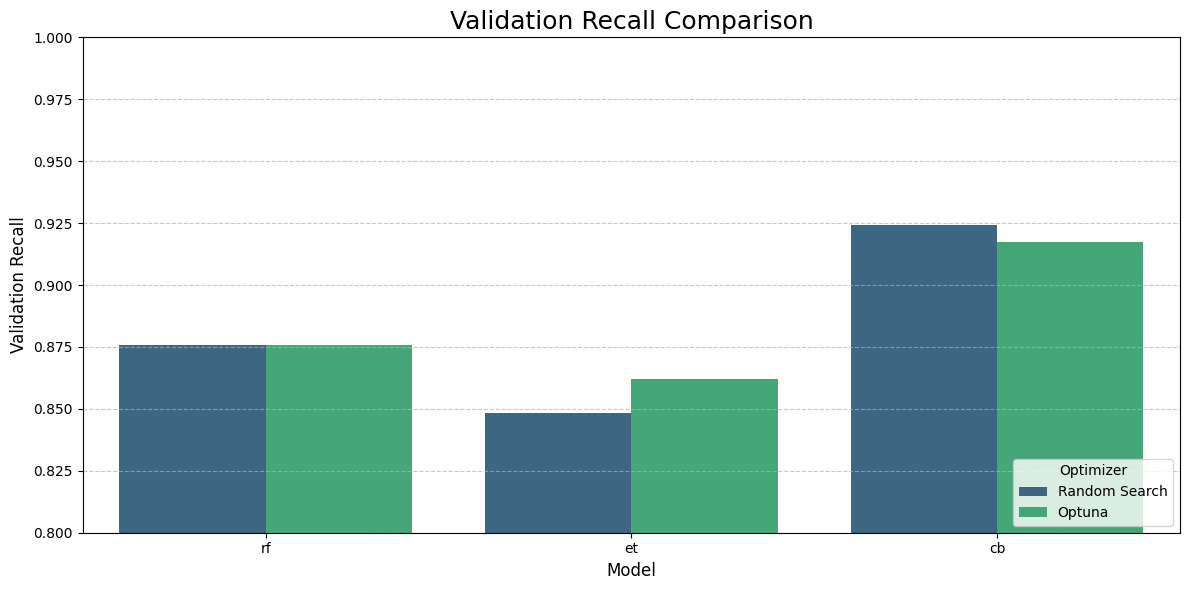

In [40]:
plot_validation_metric(df_final_comparison, "Validation Recall", "Validation Recall Comparison", ylim=(0.8, 1.0))

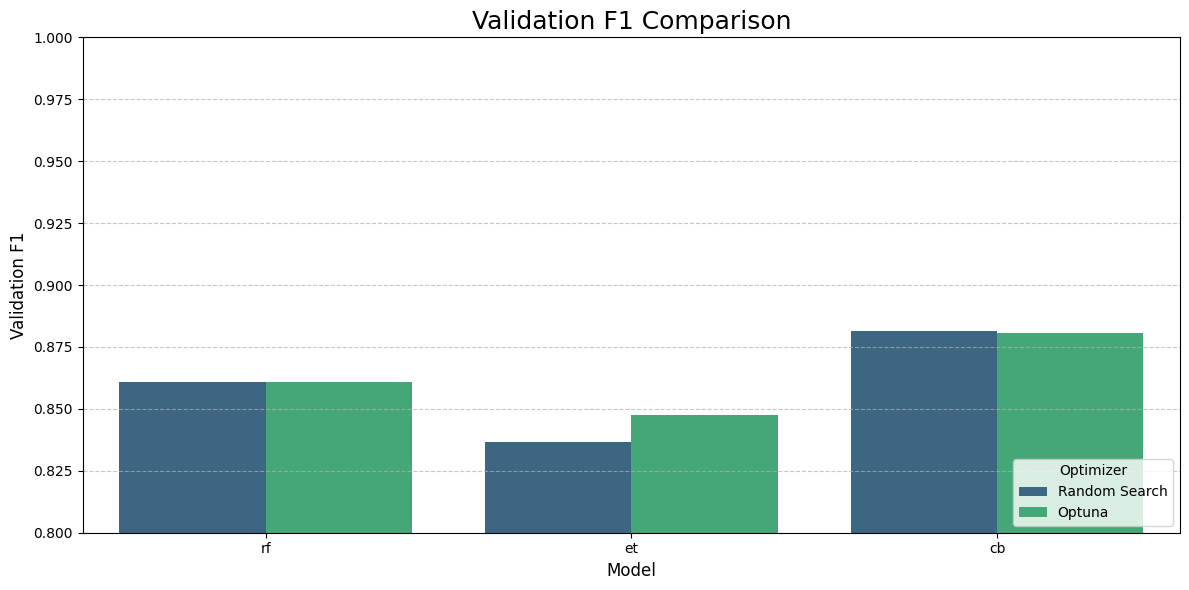

In [41]:
plot_validation_metric(df_final_comparison, "Validation F1", "Validation F1 Comparison", ylim=(0.8, 1.0))

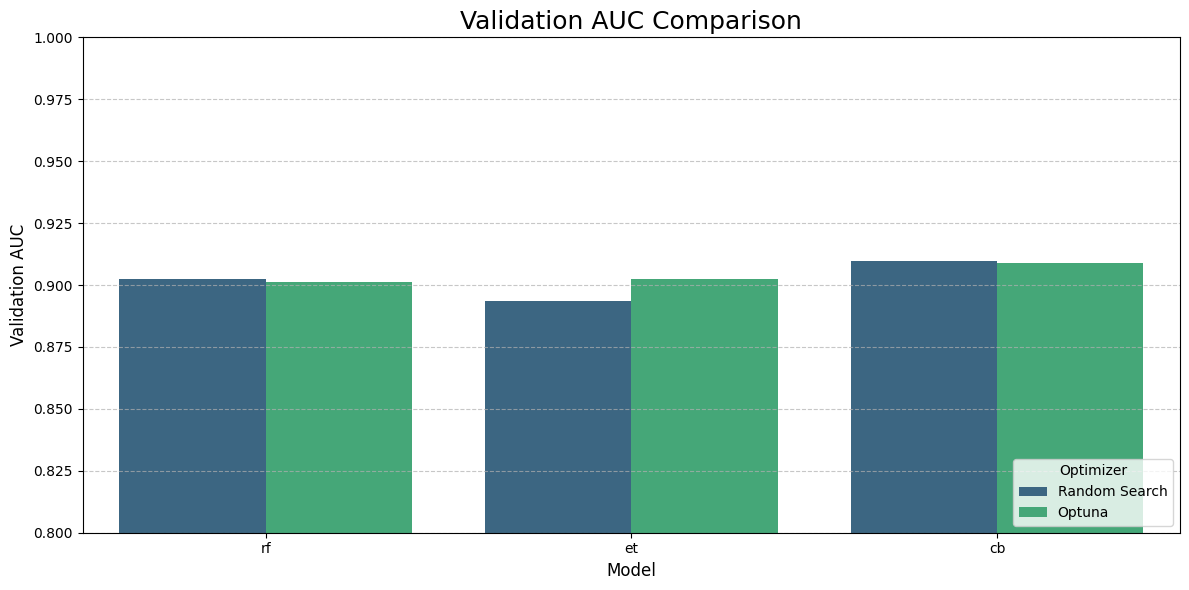

In [42]:
plot_validation_metric(df_final_comparison, "Validation AUC", "Validation AUC Comparison", ylim=(0.8, 1.0))

In [43]:
# Models selected
best_rf = best_models_randomized['rf']['best_estimator'] 
best_cb = best_models_randomized['cb']['best_estimator']
best_et = best_models_optuna['et']['best_estimator']

In [44]:
print("Best hyperparameters for the Random Forest model: ")
print(best_models_randomized['rf']['best_params'])
print("Best hyperparameters for the CatBoost model: ")
print(best_models_randomized['cb']['best_params'])
print("Best hyperparameters for the Extra Trees model: ")
print(best_models_optuna['et']['best_params'])

Best hyperparameters for the Random Forest model: 
{'model__n_estimators': 500, 'model__min_samples_split': 3, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 15, 'model__criterion': 'entropy'}
Best hyperparameters for the CatBoost model: 
{'model__scale_pos_weight': 2.13, 'model__random_strength': 2.2, 'model__min_data_in_leaf': 4, 'model__learning_rate': 0.015, 'model__l2_leaf_reg': 5.0, 'model__iterations': 800, 'model__depth': 6, 'model__border_count': 128, 'model__bagging_temperature': 0.5}
Best hyperparameters for the Extra Trees model: 
{'model__n_estimators': 800, 'model__max_depth': 10, 'model__min_samples_split': 3, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__criterion': 'entropy', 'model__bootstrap': True}


### 3) Ensemble Models:

In [45]:
def calculate_recall_weights(models, X_val, y_val):
    recalls = [recall_score(y_val, model.predict(X_val), zero_division=0) for model in models]
    total = sum(recalls)
    if total == 0:
        return [1 / len(models)] * len(models)

    return [score / total for score in recalls]

tuned_models = [best_rf, best_cb, best_et]
weights = calculate_recall_weights(tuned_models, X_val, y_val)

In [46]:
# Weighted Ensemble 
weighted = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('cb', best_cb),
        ('et', best_et),
    ],
    voting='soft',  
    weights=weights
)
weighted.fit(X_train, y_train)

# Stacking Ensemble
stacking = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('cb', best_cb),
        ('et', best_et),
    ],
    final_estimator= LogisticRegression(random_state=SEED),
    cv=CV,
    stack_method='predict_proba',
    passthrough=False,
)

stacking.fit(X_train, y_train)

StackingClassifier(cv=StratifiedKFold(n_splits=10, random_state=2025, shuffle=True),
                   estimators=[('rf',
                                Pipeline(steps=[('clean', CleanColumnNames()),
                                                ('impute',
                                                 PandasImputer(cat_cols=['sex',
                                                                         'chest_pain_type',
                                                                         'fasting_blood_sugar',
                                                                         'resting_ecg',
                                                                         'exercise_angina',
                                                                         'st_slope'],
                                                               num_cols=['age',
                                                                         'resting_bp_s',
                                                                         'cholesterol',
                                                                         'max_heart_rate',
                                                                         'oldpeak'])),
                                                ('ohe'...
                                                                     'resting_ecg',
                                                                     'exercise_angina',
                                                                     'st_slope'])),
                                                ('transform', 'passthrough'),
                                                ('resample',
                                                 BorderlineSMOTE(random_state=2025)),
                                                ('model',
                                                 ExtraTreesClassifier(bootstrap=True,
                                                                      criterion='entropy',
                                                                      max_depth=10,
                                                                      min_samples_split=3,
                                                                      n_estimators=800,
                                                                      n_jobs=-1,
                                                                      random_state=2025))]))],
                   final_estimator=LogisticRegression(random_state=2025),
                   stack_method='predict_proba')

## 9) Performance on Unseen Data:

In [47]:
all_models = [
    ('Tuned Random Forest', best_rf),
    ('Tuned CatBoost', best_cb),
    ('Tuned Extra Trees', best_et),
    ('Weighted Ensemble', weighted),
    ('Stacking Ensemble', stacking),
]

In [48]:
def calculate_classification_metrics(y_true, y_pred, y_prob=None):
    metrics_result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_prob is not None:
        if np.unique(y_true).size > 1:
            metrics_result["AUC"] = roc_auc_score(y_true, y_prob)
        else:
            metrics_result["AUC"] = np.nan

    return metrics_result

In [49]:
y_test = test_data['target']
X_test = test_data.drop('target', axis=1)

In [50]:
y_test_arr = np.asarray(y_test)

y_pred_unseen_dict = {}
y_prob_unseen_dict = {}
metric_results = []

# Bảng metric có confidence interval
ci_results = []


def bootstrap_ci(values, alpha=0.05):
    """Tính khoảng tin cậy percentile bootstrap."""
    values = np.asarray(values)
    if values.size == 0:
        return np.nan, np.nan
        
    lower = np.percentile(values, 100 * alpha / 2)
    upper = np.percentile(values, 100 * (1 - alpha / 2))
    return lower, upper


for model_name, model in all_models:
    print(f"Processing: {model_name}")

    # Chỉ dự đoán một lần cho mỗi model
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= CLASSIFICATION_THRESHOLD).astype(int)

    y_prob_unseen_dict[model_name] = y_prob
    y_pred_unseen_dict[model_name] = y_pred

    # Tính các metric gốc
    model_metrics = calculate_classification_metrics(y_true=y_test_arr, y_pred=y_pred, y_prob=y_prob)

    # Lưu dạng số để dùng cho biểu đồ
    metric_results.append({
        "Model": model_name,
        **model_metrics
    })

    # Wilson CI cho các tỷ lệ phân loại
    tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred, labels=[0, 1]).ravel()
    acc_low, acc_high = proportion_confint(count=tp + tn, nobs=len(y_test_arr), alpha=0.05, method="wilson")
    rec_low, rec_high = proportion_confint(count=tp, nobs=tp + fn, alpha=0.05, method="wilson")
    spec_low, spec_high = proportion_confint(count=tn, nobs=tn + fp, alpha=0.05, method="wilson")
    if tp + fp > 0:
        prec_low, prec_high = proportion_confint(count=tp, nobs=tp + fp, alpha=0.05, method="wilson")
    else:
        prec_low, prec_high = 0.0, 0.0
        
    # Bootstrap CI cho F1 và AUC
    boot_f1 = []
    boot_auc = []

    rng = np.random.RandomState(SEED)

    for _ in range(N_BOOTSTRAPS):
        indices = resample(
            np.arange(len(y_test_arr)),
            replace=True,
            n_samples=len(y_test_arr),
            stratify=y_test_arr,
            random_state=rng.randint(0, 1_000_000),
        )

        y_true_boot = y_test_arr[indices]
        y_pred_boot = y_pred[indices]
        y_prob_boot = y_prob[indices]

        boot_f1.append(f1_score(y_true_boot, y_pred_boot, zero_division=0))

        if np.unique(y_true_boot).size > 1:
            boot_auc.append(roc_auc_score(y_true_boot, y_prob_boot))

    f1_low, f1_high = bootstrap_ci(boot_f1)
    auc_low, auc_high = bootstrap_ci(boot_auc)

    accuracy = model_metrics["Accuracy"]
    recall = model_metrics["Recall"]
    specificity = model_metrics["Specificity"]
    precision = model_metrics["Precision"]
    f1 = model_metrics["F1 Score"]
    auc_score = model_metrics["AUC"]

    # Lưu cả số gốc và chuỗi CI
    ci_results.append({
        "Model": model_name,
        # Các cột số dùng để sắp xếp
        "_accuracy": accuracy,
        "_recall": recall,
        "_specificity": specificity,
        "_precision": precision,
        "_f1": f1,
        "_auc": auc_score,
        # Các cột trình bày
        "Accuracy (95% CI)": (f"{accuracy:.4f} " f"[{acc_low:.4f}, {acc_high:.4f}]"),
        "Recall (95% CI)": (f"{recall:.4f} " f"[{rec_low:.4f}, {rec_high:.4f}]"),
        "Specificity (95% CI)": (f"{specificity:.4f} " f"[{spec_low:.4f}, {spec_high:.4f}]"),
        "Precision (95% CI)": (f"{precision:.4f} " f"[{prec_low:.4f}, {prec_high:.4f}]"),
        "F1-Score (95% CI)": (f"{f1:.4f} " f"[{f1_low:.4f}, {f1_high:.4f}]"),
        "AUC (95% CI)": (f"{auc_score:.4f} " f"[{auc_low:.4f}, {auc_high:.4f}]"),
    })



# Bảng 1: metric dạng số để vẽ biểu đồ
df_final = (pd.DataFrame(metric_results).sort_values(by=["Recall", "Specificity", "Accuracy", "AUC"], ascending=False)
            .reset_index(drop=True))


# Bảng 2: metric kèm khoảng tin cậy
df_sorted = (pd.DataFrame(ci_results).sort_values(by=["_recall", "_specificity", "_accuracy", "_auc"],ascending=False)
    .drop(columns=["_accuracy", "_recall", "_specificity", "_precision", "_f1", "_auc"])
    .reset_index(drop=True)
)

print("Model performance with 95% confidence intervals:")
display(df_sorted)

Processing: Tuned Random Forest
Processing: Tuned CatBoost
Processing: Tuned Extra Trees
Processing: Weighted Ensemble
Processing: Stacking Ensemble
Model performance with 95% confidence intervals:


,Model,Accuracy (95% CI),Recall (95% CI),Specificity (95% CI),Precision (95% CI),F1-Score (95% CI),AUC (95% CI)
0,Tuned CatBoost,"0.9783 [0.8866, 0.9962]","1.0000 [0.8668, 1.0000]","0.9524 [0.7733, 0.9915]","0.9615 [0.8111, 0.9932]","0.9804 [0.9434, 1.0000]","0.9790 [0.9314, 1.0000]"
1,Tuned Random Forest,"0.9130 [0.7968, 0.9657]","0.9200 [0.7503, 0.9778]","0.9048 [0.7109, 0.9735]","0.9200 [0.7503, 0.9778]","0.9200 [0.8400, 0.9804]","0.9543 [0.8838, 1.0000]"
2,Weighted Ensemble,"0.9130 [0.7968, 0.9657]","0.8800 [0.7004, 0.9583]","0.9524 [0.7733, 0.9915]","0.9565 [0.7901, 0.9923]","0.9167 [0.8261, 0.9804]","0.9752 [0.9276, 1.0000]"
3,Stacking Ensemble,"0.9130 [0.7968, 0.9657]","0.8800 [0.7004, 0.9583]","0.9524 [0.7733, 0.9915]","0.9565 [0.7901, 0.9923]","0.9167 [0.8261, 0.9804]","0.9752 [0.9276, 1.0000]"
4,Tuned Extra Trees,"0.8478 [0.7178, 0.9243]","0.8400 [0.6535, 0.9360]","0.8571 [0.6536, 0.9502]","0.8750 [0.6900, 0.9566]","0.8571 [0.7500, 0.9412]","0.9581 [0.9009, 0.9962]"


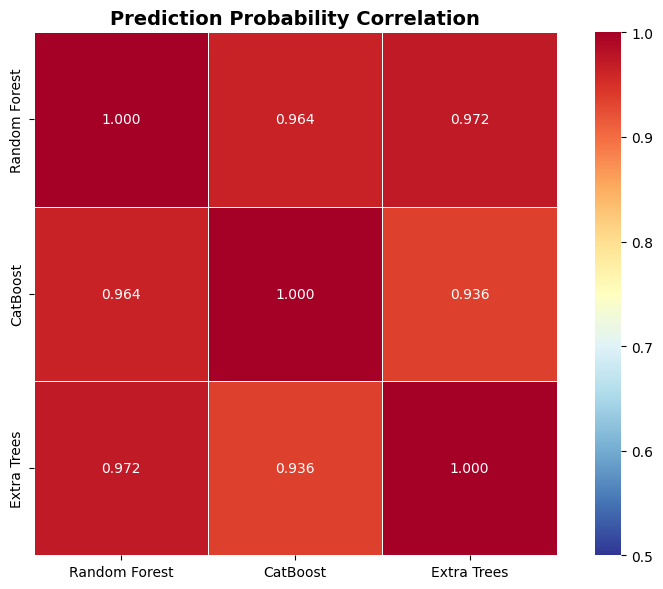

In [51]:
# Extract the prediction probability from each sub-model.
sub_model_names = {
    "Random Forest": "Tuned Random Forest",
    "CatBoost": "Tuned CatBoost",
    "Extra Trees": "Tuned Extra Trees",
}

proba_dict = {
    short_name: y_prob_unseen_dict[full_name]
    for short_name, full_name in sub_model_names.items()
}

df_proba = pd.DataFrame(proba_dict)

fig = plt.figure(figsize=(8, 6))

# Correlation matrix (probabilities)
corr_matrix = df_proba.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', 
            vmin=0.5, vmax=1.0, square=True,
            linewidths=0.5, linecolor='white')
plt.title('Prediction Probability Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

### 9.1) Model Comparison:

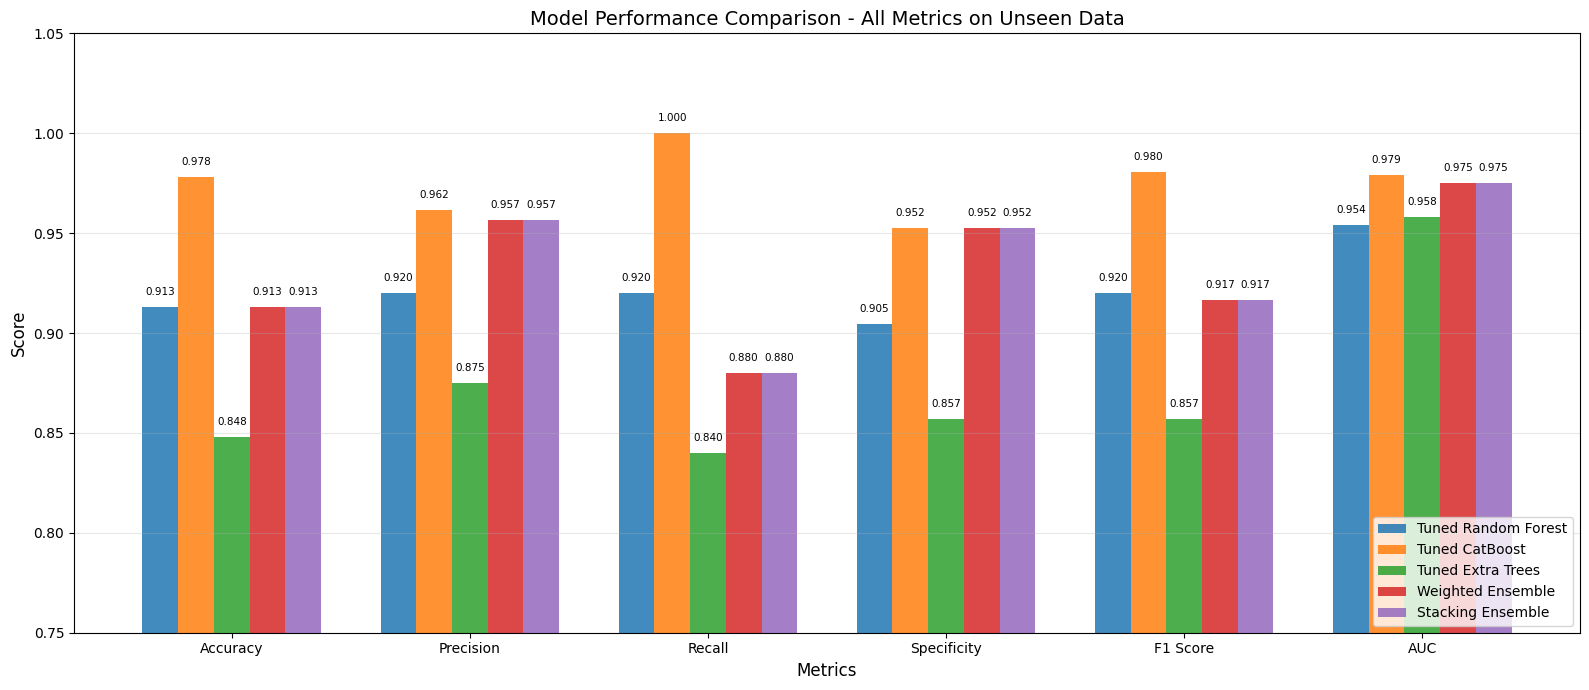

In [52]:
# Model Comparison Bar Chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1 Score', 'AUC']
n_models = len(all_models)
x = np.arange(len(metrics_to_plot))
width = 0.15 

fig, ax = plt.subplots(figsize=(16, 7))

# Center bars around each metric tick
offsets = np.arange(n_models) * width - (n_models - 1) * width / 2

for idx, (model_name, _) in enumerate(all_models):
    model_row = df_final[df_final['Model'] == model_name].iloc[0]
    values = [model_row[metric] for metric in metrics_to_plot]
    bars = ax.bar(x + offsets[idx], values, width, label=model_name, alpha=0.85)

    # Add value labels
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, 
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison - All Metrics on Unseen Data', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim([0.75, 1.05]) 
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

### 9.2) Confusion matrix:

In [53]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

    cm_display.plot()
    plt.title(f"Confusion Matrix for {model_name} Model")
    plt.show()
    plt.close()

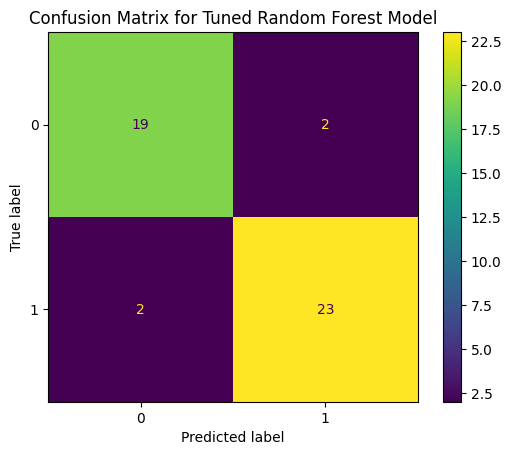

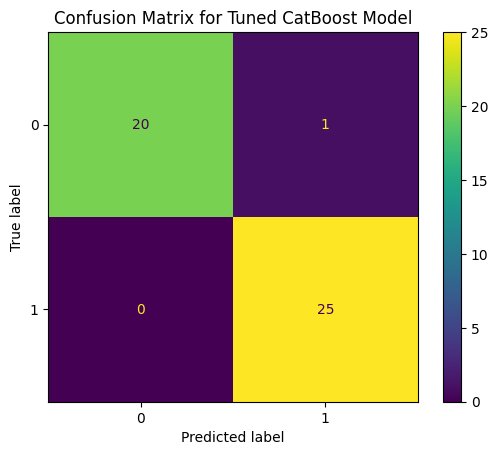

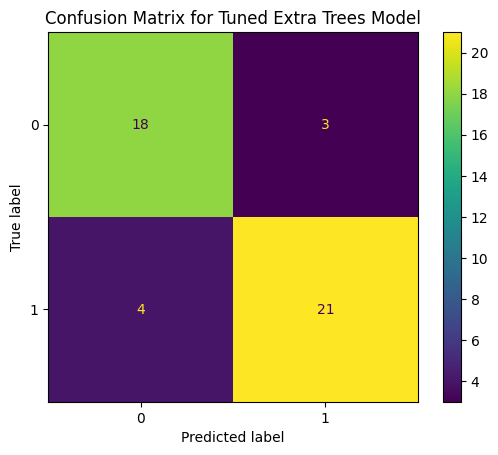

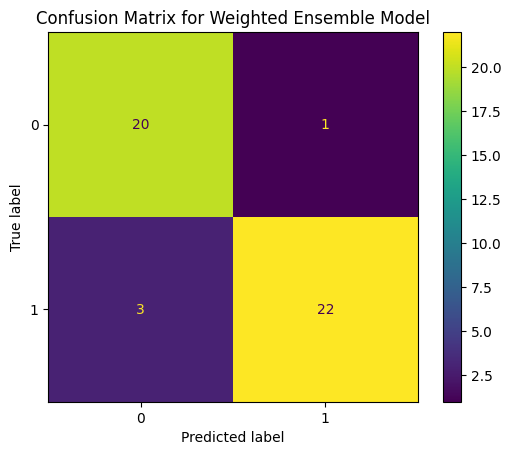

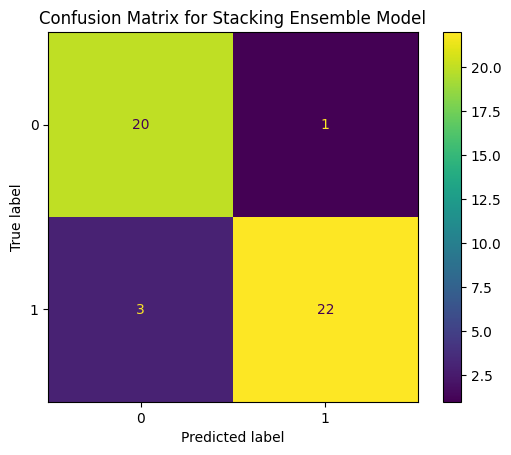

In [54]:
for model_name, _ in all_models:
    plot_confusion_matrix(y_true=y_test, y_pred=y_pred_unseen_dict[model_name], model_name=model_name)

### 9.3) ROC curve:

In [55]:
def plot_roc(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})",)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle="--", label="Random Classifier")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve for {model_name}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

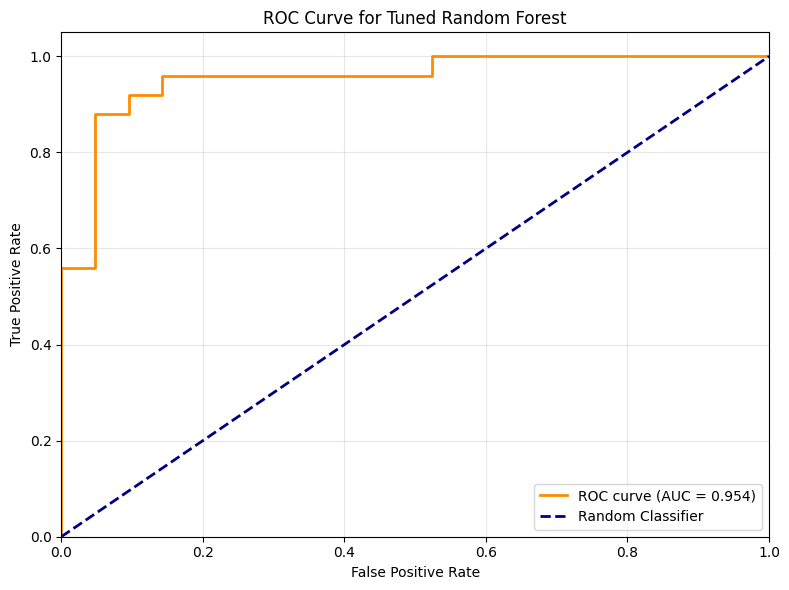

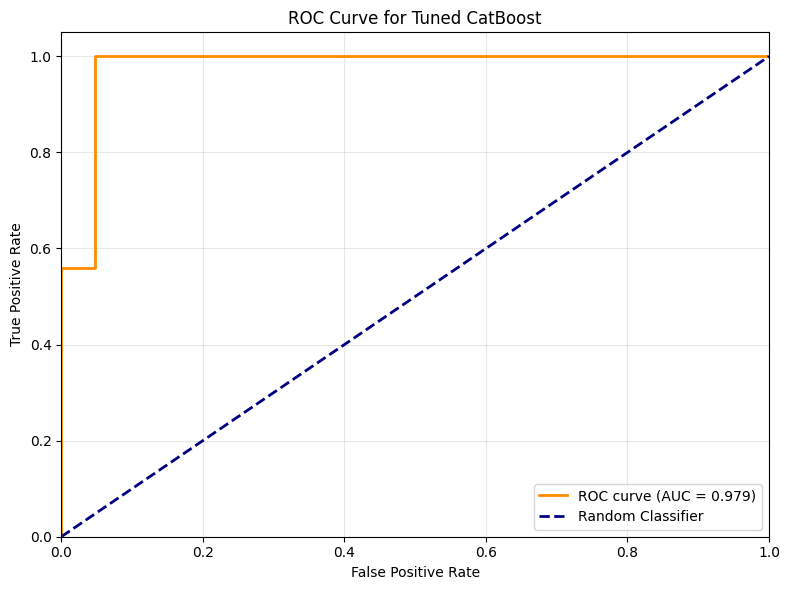

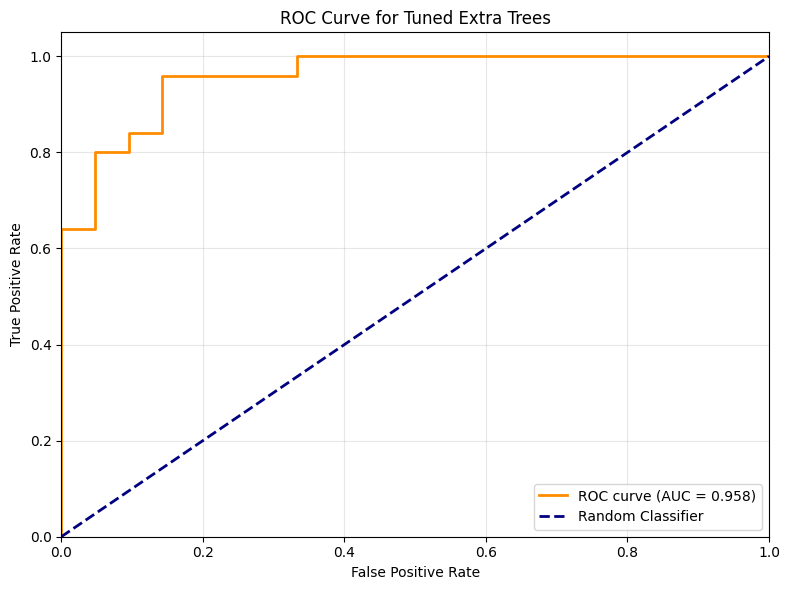

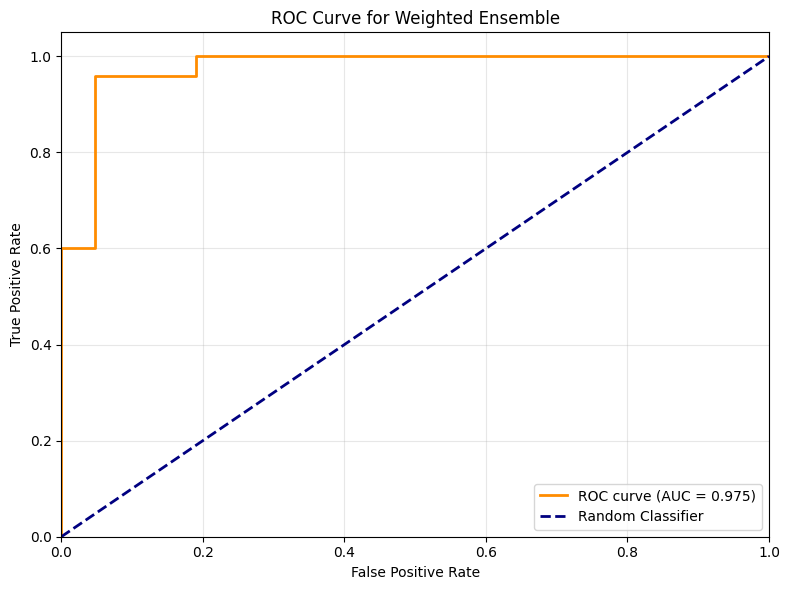

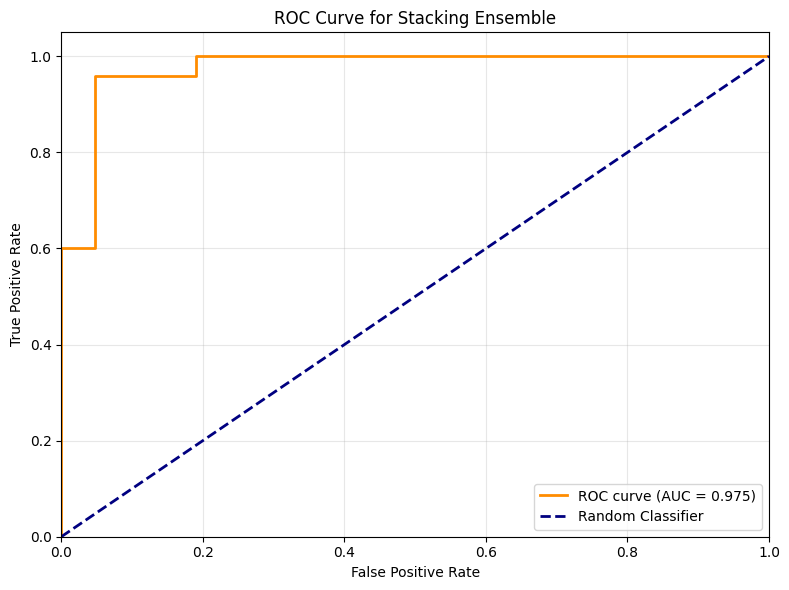

In [56]:
for model_name, _ in all_models:
    plot_roc(y_true=y_test, y_prob=y_prob_unseen_dict[model_name], model_name=model_name)

### 9.4) Precision-Recall Curve:

In [57]:
def plot_precision_recall_curve(y_true, y_prob, model_name):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    no_skill = np.mean(y_true)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='darkorange', lw=2, label=f"PR curve (AUC = {pr_auc:.3f})")
    plt.axhline(y=no_skill, lw=2, linestyle="--", label="No Skill Classifier")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve for {model_name}")
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

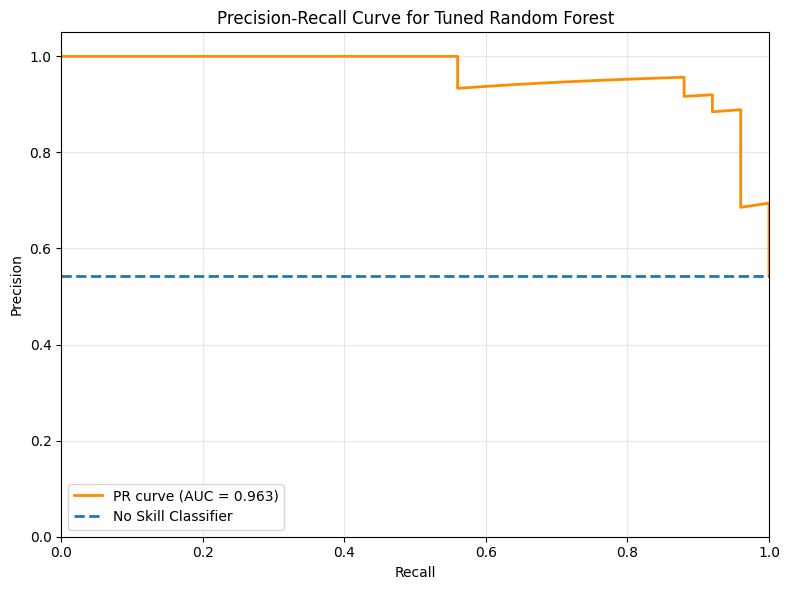

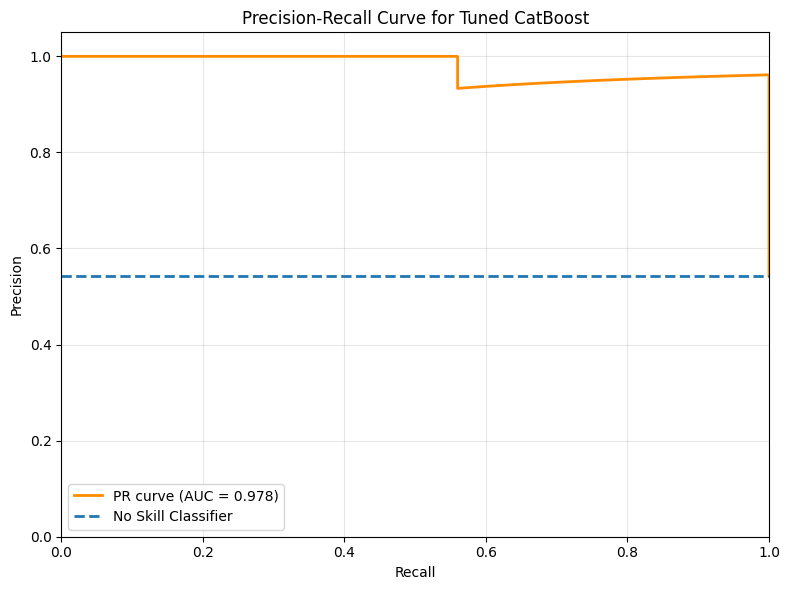

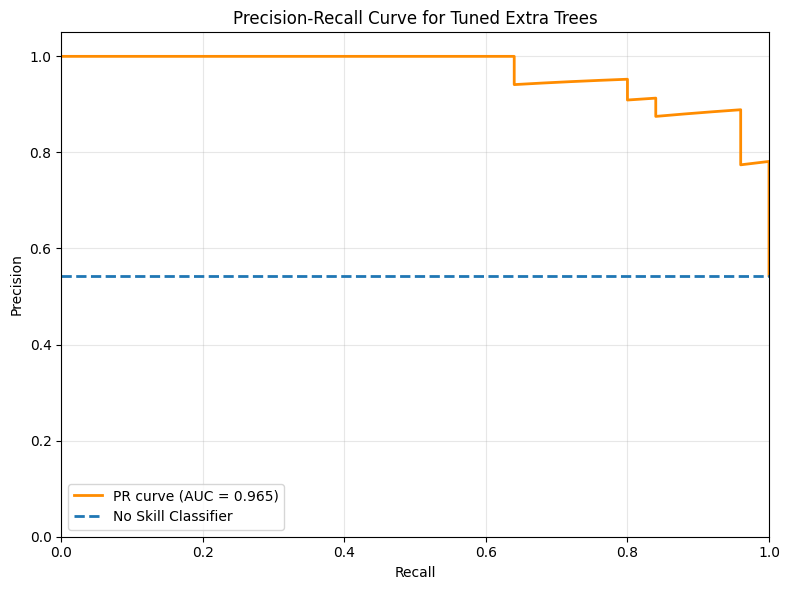

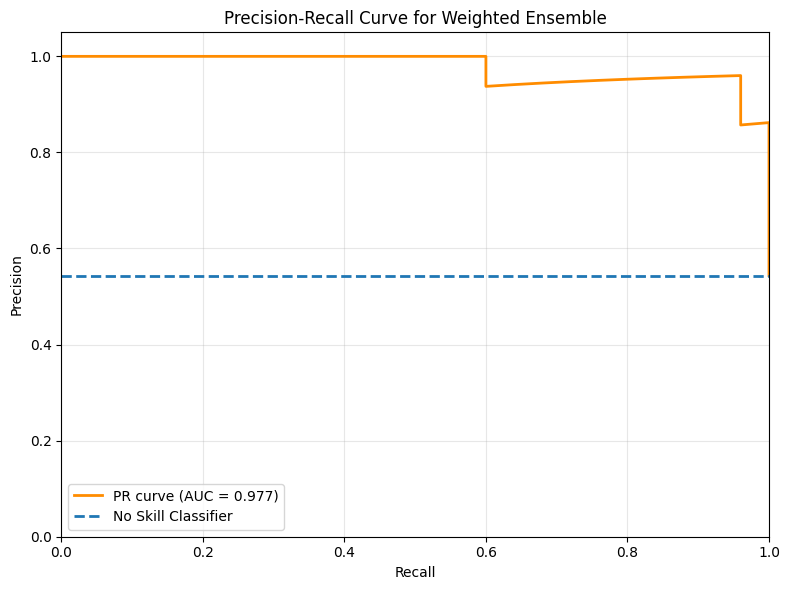

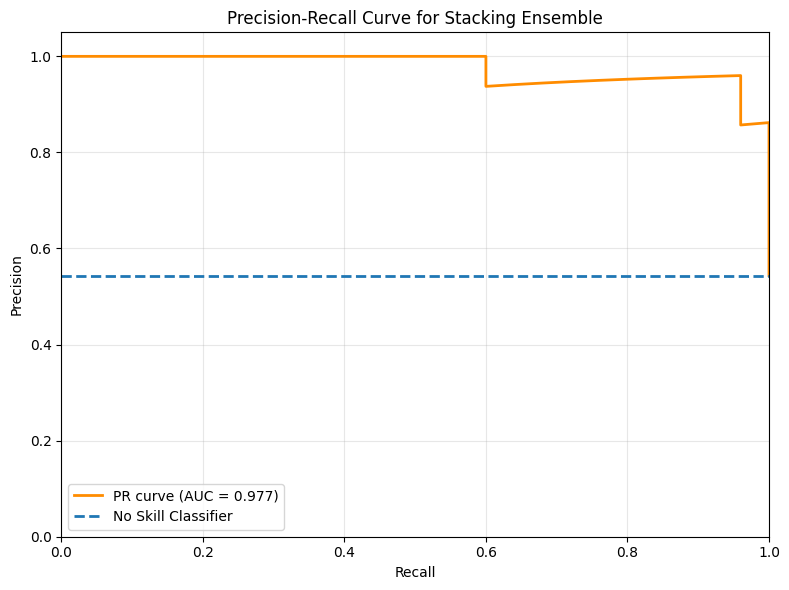

In [58]:
for model_name, _ in all_models:
    plot_precision_recall_curve(y_true=y_test, y_prob=y_prob_unseen_dict[model_name], model_name=model_name)

### 9.5) Wilcoxon signed-rank:

In [59]:
fold_recall_scores = {name: [] for name, _ in all_models}

for fold,(train_idx,val_idx) in enumerate(CV.split(X_train,y_train), start=1):
    print(f"Fold {fold}/{N_SPLITS}")

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    for model_name, model in all_models:
        fitted_model = clone(model)
        fitted_model.fit(X_fold_train,y_fold_train)
        y_prob = fitted_model.predict_proba(X_fold_val)[:,1]
        y_pred = (y_prob >= CLASSIFICATION_THRESHOLD).astype(int)
        fold_recall = recall_score(y_fold_val, y_pred, zero_division=0)
        fold_recall_scores[model_name].append(fold_recall)

Fold 1/10
Fold 2/10
Fold 3/10
Fold 4/10
Fold 5/10
Fold 6/10
Fold 7/10
Fold 8/10
Fold 9/10
Fold 10/10


In [60]:
score_df = pd.DataFrame(fold_recall_scores)
score_df

,Tuned Random Forest,Tuned CatBoost,Tuned Extra Trees,Weighted Ensemble,Stacking Ensemble
0,0.911765,0.911765,0.911765,0.911765,0.911765
1,0.970588,0.970588,0.970588,0.970588,0.970588
2,0.911765,0.941176,0.882353,0.941176,0.941176
3,0.911765,0.911765,0.911765,0.911765,0.911765
4,0.941176,0.941176,0.911765,0.941176,0.941176
5,0.970588,0.970588,0.970588,0.970588,0.970588
6,0.941176,0.970588,0.911765,0.911765,0.911765
7,0.941176,0.970588,0.852941,0.970588,0.941176
8,0.848485,0.878788,0.818182,0.848485,0.848485
9,0.969697,0.969697,0.969697,0.939394,0.939394


In [61]:
wilcoxon_results = []
raw_p = []

pairs = list(combinations(score_df.columns, 2))


for model_a, model_b in pairs:
    s1 = score_df[model_a]
    s2 = score_df[model_b]
    stat, p = wilcoxon(s1,s2)

    raw_p.append(p)
    wilcoxon_results.append({
        "Model A": model_a,
        "Model B": model_b,
        "Mean Recall A": round(s1.mean(),4),
        "Mean Recall B": round(s2.mean(),4),
        "Wilcoxon Statistic": round(stat,4),
        "Raw p-value":p
    })



# Holm correction
reject, p_adj, _, _ = multipletests(raw_p, alpha=0.05, method="holm")

for i in range(len(wilcoxon_results)):
    wilcoxon_results[i]["Holm p-value"] = round(p_adj[i], 4)
    wilcoxon_results[i]["Statistical significance"] = ("Significant" if reject[i] else "Not significant")


# Result
wilcoxon_df = (pd.DataFrame(wilcoxon_results).sort_values(by="Holm p-value", ascending=True)).reset_index(drop=True)
display(wilcoxon_df)

,Model A,Model B,Mean Recall A,Mean Recall B,Wilcoxon Statistic,Raw p-value,Holm p-value,Statistical significance
0,Tuned Random Forest,Tuned Extra Trees,0.9318,0.9111,0.0,0.0625,0.625,Not significant
1,Tuned CatBoost,Tuned Extra Trees,0.9437,0.9111,0.0,0.0625,0.625,Not significant
2,Tuned Random Forest,Weighted Ensemble,0.9318,0.9317,4.0,1.0000,1.000,Not significant
3,Tuned Random Forest,Tuned CatBoost,0.9318,0.9437,0.0,0.1250,1.000,Not significant
4,Tuned Random Forest,Stacking Ensemble,0.9318,0.9288,1.5,0.7500,1.000,Not significant
5,Tuned CatBoost,Weighted Ensemble,0.9437,0.9317,0.0,0.2500,1.000,Not significant
6,Tuned CatBoost,Stacking Ensemble,0.9437,0.9288,0.0,0.1250,1.000,Not significant
7,Tuned Extra Trees,Weighted Ensemble,0.9111,0.9317,2.5,0.2500,1.000,Not significant
8,Tuned Extra Trees,Stacking Ensemble,0.9111,0.9288,2.5,0.2500,1.000,Not significant
9,Weighted Ensemble,Stacking Ensemble,0.9317,0.9288,0.0,1.0000,1.000,Not significant


## 10) Ablation Study:

In [62]:
# Tuned Catboost parameters
cb_best_params = best_models_randomized['cb']['best_params'].copy()
cb_best_params

{'model__scale_pos_weight': 2.13,
 'model__random_strength': 2.2,
 'model__min_data_in_leaf': 4,
 'model__learning_rate': 0.015,
 'model__l2_leaf_reg': 5.0,
 'model__iterations': 800,
 'model__depth': 6,
 'model__border_count': 128,
 'model__bagging_temperature': 0.5}

In [63]:
ablation_configs = {
    # Cấu hình 1 - Mặc định
    "Baseline": {
        "balance_mode": False,
        "scale_pos_weight": 1.0
    },
    # Cấu hình 2 - Chỉ dùng BorderlineSMOTE
    "SMOTE_only": {
        "balance_mode": True,
        "scale_pos_weight": 1.0
    },
    # Cấu hình 3 - Chỉ dùng scale_pos_weight
    "Weight_only": {
        "balance_mode": False,
        "scale_pos_weight": 2.13
    },
    # Cấu hình 4 - Đề xuất
    "Full_pipeline": {
        "balance_mode": True,
        "scale_pos_weight": 2.13
    }
}

In [64]:
ablation_results = {}
ablation_table = []

for config_name, cfg in ablation_configs.items():
    print(f"\nTraining with {config_name} config")

    pipe = build_pipeline(
        X_train,
        model="cb",
        balance_mode=cfg["balance_mode"],
        random_state=SEED
    )

    current_params = cb_best_params.copy()

    # thay đổi scale_pos_weight
    current_params["model__scale_pos_weight"] = cfg["scale_pos_weight"]
    pipe.set_params(**current_params)

    ablation_cv_results = cross_validate(pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=1)

    result = {
        "Configuration": config_name,
        "SMOTE": cfg["balance_mode"],
        "scale_pos_weight": cfg["scale_pos_weight"],
        "Accuracy": ablation_cv_results["test_accuracy"].mean(),
        "Recall": ablation_cv_results["test_recall"].mean(),
        "Specificity": ablation_cv_results["test_specificity"].mean(),
        "Precision": ablation_cv_results["test_precision"].mean(),
        "F1 Score": ablation_cv_results["test_f1"].mean(),
        "AUC": ablation_cv_results["test_roc_auc"].mean()
    }

    ablation_table.append(result)
    pipe.fit(X_train, y_train)
    ablation_results[config_name] = {"model": pipe, "cv_results": ablation_cv_results}

df_ablation = pd.DataFrame(ablation_table).sort_values(["Recall", "Specificity", "F1 Score", "AUC"], ascending=False)

df_ablation


Training with Baseline config

Training with SMOTE_only config

Training with Weight_only config

Training with Full_pipeline config


,Configuration,SMOTE,scale_pos_weight,Accuracy,Recall,Specificity,Precision,F1 Score,AUC
3,Full_pipeline,True,2.13,0.890164,0.943672,0.823413,0.871018,0.905377,0.935143
2,Weight_only,False,2.13,0.873770,0.934670,0.797487,0.854033,0.891783,0.932965
1,SMOTE_only,True,1.00,0.883607,0.907932,0.852778,0.885269,0.895987,0.938078
0,Baseline,False,1.00,0.875410,0.907843,0.834259,0.874980,0.889510,0.934601


In [65]:
ablation_test = []

for configuration_name, obj in ablation_results.items():
    model = obj["model"]
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= CLASSIFICATION_THRESHOLD).astype(int)

    ablation_metrics = calculate_classification_metrics(y_true=y_test, y_pred=y_pred, y_prob=y_prob)

    ablation_test.append({
        "Configuration": configuration_name,
        **ablation_metrics
    })

df_ablation_test = pd.DataFrame(ablation_test).sort_values(["Recall", "Specificity", "F1 Score"], ascending=False)

df_ablation_test

,Configuration,Accuracy,Recall,Specificity,Precision,F1 Score,AUC
3,Full_pipeline,0.978261,1.00,0.952381,0.961538,0.980392,0.979048
2,Weight_only,0.913043,0.96,0.857143,0.888889,0.923077,0.958095
0,Baseline,0.913043,0.92,0.904762,0.920000,0.920000,0.950476
1,SMOTE_only,0.913043,0.88,0.952381,0.956522,0.916667,0.969524


In [66]:
# Save tuned model
joblib.dump(best_rf, 'best_rf_model.pkl')
joblib.dump(best_et, 'best_et_model.pkl')
joblib.dump(best_cb, 'best_cb_model.pkl')

# Save ensemble model
joblib.dump(weighted, 'weighted_ensemble_model.pkl')
joblib.dump(stacking, 'stacking_ensemble_model.pkl')

print("Save successful!")

Save successful!


## 11) XAI:

In [67]:
shap_model_pipeline = best_cb

In [68]:
def transform_before_model(pipeline, X):
    transformed = X.copy()

    for _, step in pipeline.steps[:-1]:
        if hasattr(step, "transform"):
            transformed = step.transform(transformed)

    if isinstance(transformed, pd.DataFrame):
        return transformed.reset_index(drop=True)

    return pd.DataFrame(transformed)

### 11.1) Global Explanation:

In [69]:
# Prepare data for explain
X_explain = df.drop('target', axis=1).copy().reset_index(drop=True)
catboost_model = shap_model_pipeline[-1]

# Preprocess
X_explain_transformed = transform_before_model(shap_model_pipeline, X_explain)

print("Shape after preprocessing:", X_explain_transformed.shape)

# TreeSHAP
print("\nRunning TreeSHAP...")
background = shap.sample(
    X_explain_transformed,
    100,
    random_state=SEED
)

explainer = shap.TreeExplainer(
    catboost_model,
    data=background,
    model_output="probability",
    feature_perturbation="interventional"
)

shap_values = explainer(X_explain_transformed)

# Binary classification
if hasattr(shap_values, "values") and len(shap_values.values.shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

print("\nTreeSHAP is complete!")

Shape after preprocessing: (918, 21)

Running TreeSHAP...


 99%|===================| 905/918 [01:06<00:00]        


TreeSHAP is complete!


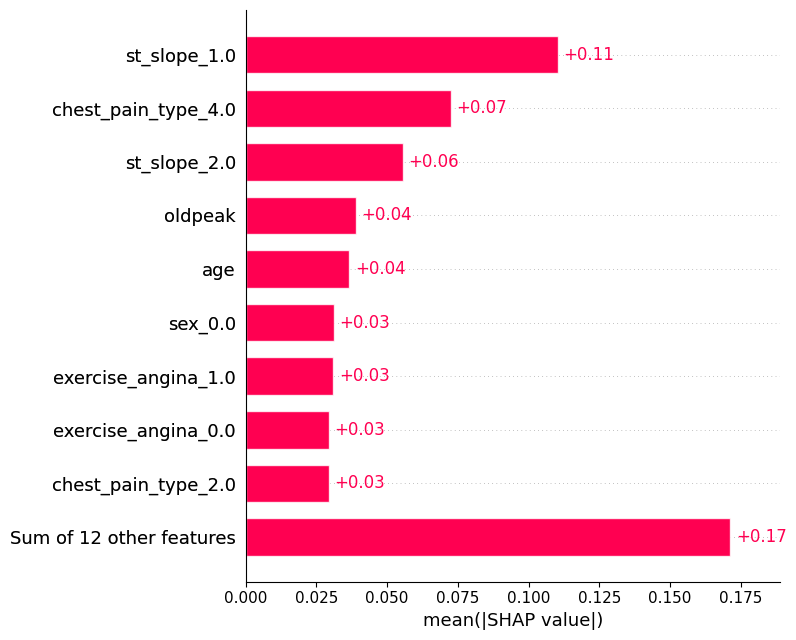

In [70]:
# Global explanation
shap.plots.bar(shap_values_class1, max_display=10, show=False)
plt.tight_layout()
plt.show()
plt.close()

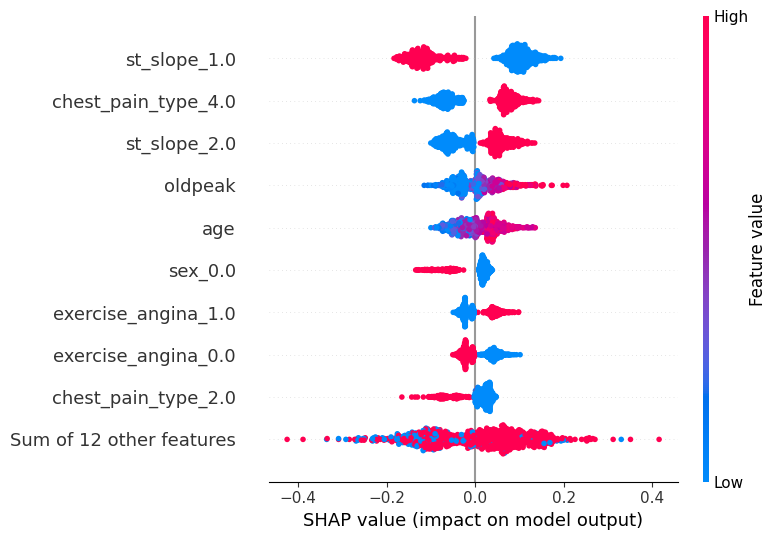

In [71]:
shap.plots.beeswarm(shap_values_class1, max_display=10, show=False)
plt.tight_layout()
plt.show()
plt.close()

### 11.2) Local Explanation:

In [72]:
X_local = X_test.copy().reset_index(drop=True)
y_local = y_test.copy().reset_index(drop=True)

X_local_transformed = transform_before_model(shap_model_pipeline, X_local)

print("Shape after preprocessing:", X_local_transformed.shape)

Shape after preprocessing: (46, 21)


In [73]:
shap_values_test = explainer(X_local_transformed)

if hasattr(shap_values_test, "values") and len(shap_values_test.values.shape) == 3:
    shap_values_test = shap_values_test[:, :, 1]

print("Local SHAP values are ready!")

Local SHAP values are ready!


In [74]:
y_proba = shap_model_pipeline.predict_proba(X_local)[:, 1]
y_pred = (y_proba >= CLASSIFICATION_THRESHOLD).astype(int)

explain_results = pd.DataFrame({
    "actual": y_local,
    "predicted": y_pred,
    "prob_class_1": y_proba
})

explain_results["case_type"] = np.select(
    [((explain_results["actual"] == 0)
    & (explain_results["predicted"] == 0)
    ),
      ((explain_results["actual"] == 1)
        & (explain_results["predicted"] == 1)
    ),
       ((explain_results["actual"] == 1)
        & (explain_results["predicted"] == 0)
    ),
       ((explain_results["actual"] == 0)
        & (explain_results["predicted"] == 1)
    ),
    ],
    ["TN", "TP", "FN", "FP"],
    default="Unknown",
)

print(explain_results["case_type"].value_counts())

case_type
TP    25
TN    20
FP     1
Name: count, dtype: int64


In [75]:
def explain_case(case_type,select_by="first",threshold=CLASSIFICATION_THRESHOLD,max_display=10):
    """
    case_type: "TN", "TP", "FN", "FP"
    select_by:
        - "first": lấy mẫu đầu tiên
        - "highest_prob": lấy mẫu có prob_class_1 cao nhất
        - "lowest_prob": lấy mẫu có prob_class_1 thấp nhất
        - "closest_threshold": lấy mẫu gần threshold nhất
    """

    case_df = explain_results[explain_results["case_type"] == case_type].copy()

    if case_df.empty:
        print(f"Không có mẫu nào thuộc nhóm {case_type}.")
        return

    if select_by == "first":
        selected_index = case_df.index[0]

    elif select_by == "highest_prob":
        selected_index = case_df["prob_class_1"].idxmax()

    elif select_by == "lowest_prob":
        selected_index = case_df["prob_class_1"].idxmin()

    elif select_by == "closest_threshold":
        case_df["distance_to_threshold"] = abs(case_df["prob_class_1"] - threshold)
        selected_index = case_df["distance_to_threshold"].idxmin()

    else:
        raise ValueError(
            "select_by phải là một trong: 'first', 'highest_prob', 'lowest_prob', 'closest_threshold'"
        )

    # Lấy thông tin mẫu
    actual_label = y_local.loc[selected_index]
    pred_prob = explain_results.loc[selected_index, "prob_class_1"]
    pred_value = explain_results.loc[selected_index, "predicted"]

    actual_text = "Heart Disease" if actual_label == 1 else "No Disease"
    pred_text = "Heart Disease" if pred_value == 1 else "No Disease"

    # In thông tin dự đoán
    print(f"Explain the prediction for the {case_type} observation:")
    print(f"  Original index: {selected_index}")
    print(f"  SHAP position index: {selected_index}")
    print(f"  Actual label: {actual_label} ({actual_text})")
    print(f"  Predictive probability (class 1): {pred_prob:.4f}")
    print(f"  Predicted result: {pred_value} ({pred_text})")

    # In ra mẫu được chọn dưới dạng bảng
    sample_info = X_local.loc[[selected_index]].copy()
    sample_info["actual"] = actual_label
    sample_info["predicted"] = pred_value
    sample_info["prob_class_1"] = pred_prob
    sample_info["case_type"] = case_type

    print("\nSelected sample:")
    display(sample_info)

    # Vẽ waterfall plot
    shap.plots.waterfall(shap_values_test[selected_index], max_display=max_display, show=False)

    plt.tight_layout()
    plt.show()
    plt.close()

Explain the prediction for the TP observation:
  Original index: 27
  SHAP position index: 27
  Actual label: 1 (Heart Disease)
  Predictive probability (class 1): 0.9955
  Predicted result: 1 (Heart Disease)

Selected sample:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,actual,predicted,prob_class_1,case_type
27,69,1,4,142.0,210.0,1,1,112,1,1.5,2.0,1,1,0.995545,TP


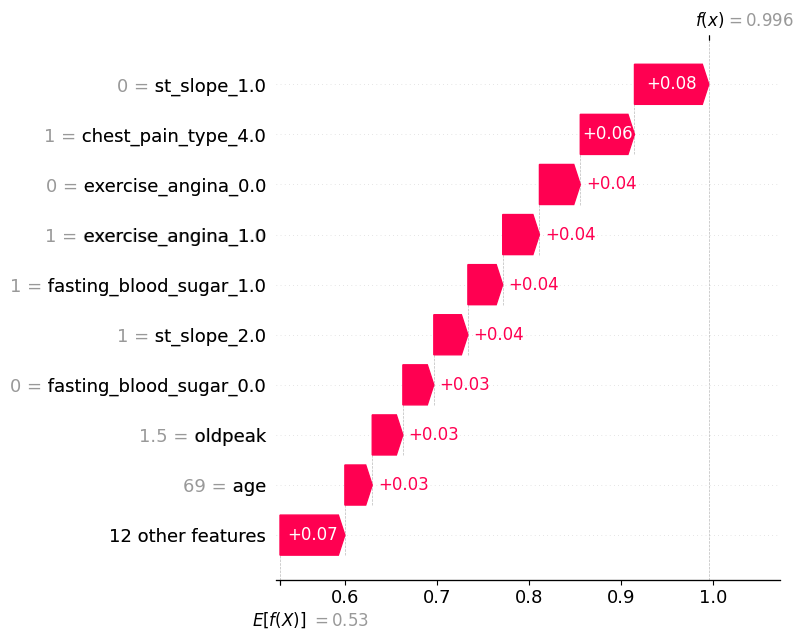

In [76]:
explain_case("TP", select_by="highest_prob")

Explain the prediction for the TN observation:
  Original index: 11
  SHAP position index: 11
  Actual label: 0 (No Disease)
  Predictive probability (class 1): 0.0114
  Predicted result: 0 (No Disease)

Selected sample:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,actual,predicted,prob_class_1,case_type
11,54,0,2,130.0,253.0,0,1,155,0,0.0,1.0,0,0,0.011402,TN


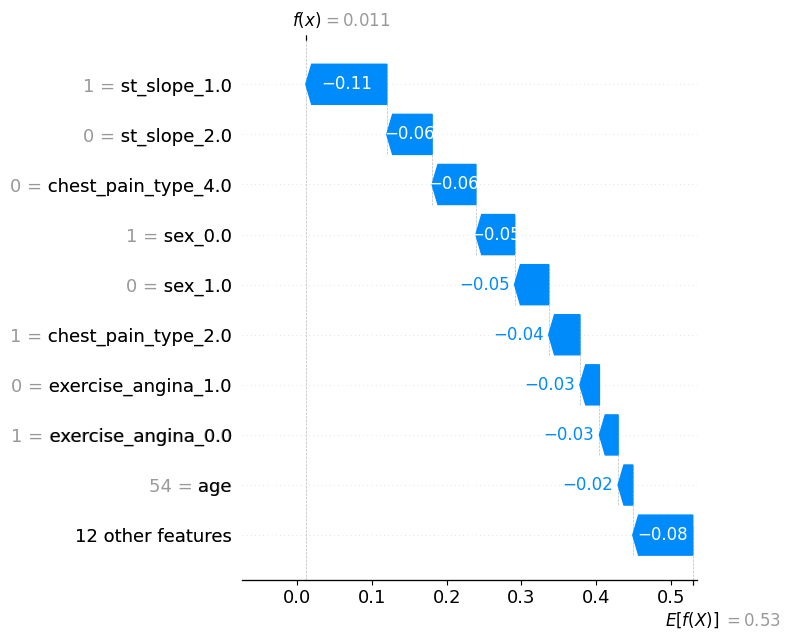

In [77]:
explain_case("TN", select_by="lowest_prob")

Explain the prediction for the FP observation:
  Original index: 23
  SHAP position index: 23
  Actual label: 0 (No Disease)
  Predictive probability (class 1): 0.9275
  Predicted result: 1 (Heart Disease)

Selected sample:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,actual,predicted,prob_class_1,case_type
23,59,1,4,154.0,NaN,0,1,131,1,1.5,1.0,0,1,0.92749,FP


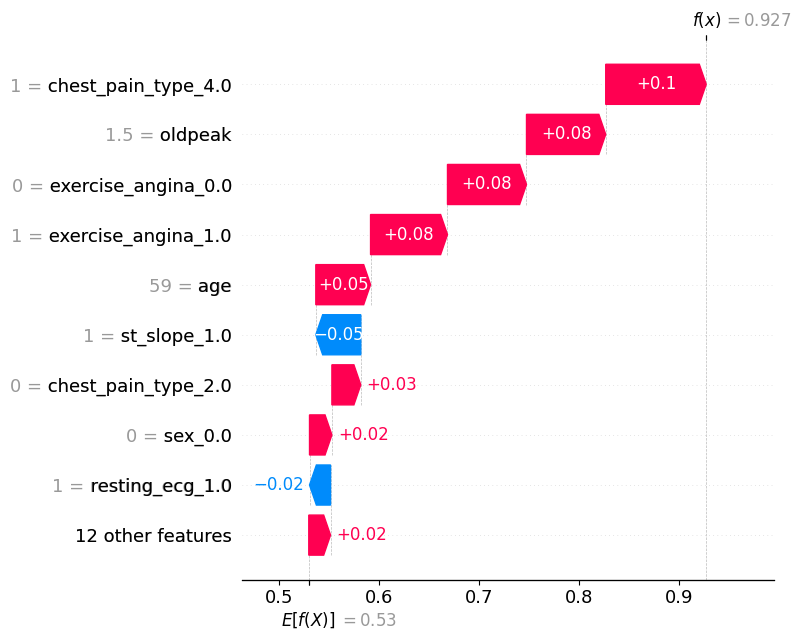

In [78]:
explain_case("FP", select_by="closest_threshold")